# Multimodal Movie Recommendation System

This notebook presents a multimodal movie recommendation project developed for the **Neural Networks & Deep Learning** course at the National Technical University of Athens (NTUA).

The project combines **computer vision**, **natural language processing**, and **graph neural networks** to study how different movie representations affect recommendation performance.

The workflow progresses from visual and textual representation learning to heterogeneous user–movie graph construction and GraphSAGE-based link prediction.

> **Attribution:** Parts of the experimental framework, including the GraphSAGE architecture and training pipeline, were provided with the course assignment. The project work focused on feature construction, multimodal representation, integration with the graph framework, experimentation, evaluation, and analysis.


## Data Preparation
This section contains the **mandatory data preparation phase**. Read through the explanations to understand *why* we are formatting the data this way before you begin building your models.

You can use the provided curated dataset for consistency, or recreate it yourself by running the following cells. Note that recreating the data requires a [TMDB API](https://developer.themoviedb.org/docs/getting-started) key.



### Raw Data

The project uses two MovieLens datasets from GroupLens:

- **MovieLens Latest Small** provides the user–movie interaction graph used for recommendation experiments.
- **MovieLens 25M** provides a separate pool of movies used for training the visual and textual representation models.

Using separate movie sets prevents the representation models from being trained directly on the movies used in the recommendation graph.

In [37]:
import os

# Create a datasets directory
os.makedirs('datasets', exist_ok=True)

# Download and unzip the datasets
!wget -q https://files.grouplens.org/datasets/movielens/ml-latest-small.zip
!wget -q https://files.grouplens.org/datasets/movielens/ml-25m.zip
!unzip -q -o ml-latest-small.zip -d datasets/
!unzip -q -o ml-25m.zip -d datasets/

---
### **Stratified Sampling**
To ensure our CV and NLP models generalize well to the final `ml-latest-small` graph, we perform **stratified sampling**. We calculate the distribution of "Decade + Primary Genre" in the small dataset, and force our training samples to match that exact distribution. If we train our CV and NLP models on a random subset of 15,000 movies from the massive 25M dataset, we might end up with a skewed distribution (e.g., too many 2010s Action movies and not enough 1950s Dramas) compared to our target ml-latest-small graph.

In [11]:
import pandas as pd
import numpy as np

def extract_metadata(df):
    """Extracts Decade and Primary Genre to create a sampling stratum."""
    df['year'] = df['title'].str.extract(r'\((\d{4})\)').astype(float)
    df['decade'] = (df['year'] // 10 * 10).fillna(0).astype(int)
    df['primary_genre'] = df['genres'].str.split('|').str[0]
    df['stratum'] = df['decade'].astype(str) + "_" + df['primary_genre']
    return df

In [12]:
print("Loading datasets...")
small_movies = pd.read_csv('datasets/ml-latest-small/movies.csv')
small_links = pd.read_csv('datasets/ml-latest-small/links.csv')

large_movies = pd.read_csv('datasets/ml-25m/movies.csv')
large_links = pd.read_csv('datasets/ml-25m/links.csv')

print("Processing metadata for stratified sampling...")
small_movies = extract_metadata(small_movies)
large_movies = extract_metadata(large_movies)

# Calculate target distribution from the small graph
target_distribution = small_movies['stratum'].value_counts(normalize=True)


Loading datasets...
Processing metadata for stratified sampling...


We prevent data leakage by creating a **disjoint** set of 15,000 movies to use for training on the image/text modalities.

In [13]:
# Find disjoint set (Movies in 25M that are NOT in latest-small)
small_ids = set(small_movies['movieId'])
disjoint_movies = large_movies[~large_movies['movieId'].isin(small_ids)].copy()

# Merge with TMDB links
# Discard movies with missing TMDB ids (database for plot summaries/posters)
disjoint_full = pd.merge(disjoint_movies, large_links, on='movieId')
disjoint_full = disjoint_full.dropna(subset=['tmdbId'])
disjoint_full['tmdbId'] = disjoint_full['tmdbId'].astype(int)

# Map weights and sample
disjoint_full['sample_weight'] = disjoint_full['stratum'].map(target_distribution).fillna(0)
train_subset = disjoint_full.sample(n=15000, weights='sample_weight', random_state=42)

# Merge small_movies with their TMDB links as well
small_full = pd.merge(small_movies, small_links, on='movieId')
small_full = small_full.dropna(subset=['tmdbId'])
small_full['tmdbId'] = small_full['tmdbId'].astype(int)

columns_to_keep = ['movieId', 'title', 'genres', 'tmdbId']
train_subset = train_subset[columns_to_keep]
small_full = small_full[columns_to_keep]

In [14]:
print(f"Stratified Training Subset: {len(train_subset)} movies.")
print(f"ML-Small Inference Target: {len(small_full)} movies.")

Stratified Training Subset: 15000 movies.
ML-Small Inference Target: 9734 movies.


## Part 1 — Visual Representation Learning

Movie posters are used as the visual modality of the recommendation pipeline.

A convolutional neural network is trained for **multi-label genre classification**, since each movie can belong to multiple genres simultaneously. The learned visual representation is subsequently extracted and used as a movie-node feature in the graph-based recommendation system.

### **The PyTorch Dataset**
Let's create a PyTorch Custom Dataset for the CV portion.

### Dataset

The experiments use preprocessed movie metadata, plot summaries, and poster data stored locally in the `datasets/` directory.

The prepared datasets used in the experiments are loaded below. Dataset preparation was performed separately from the main experimental pipeline.

In [ ]:
import pandas as pd

# Load train_metadata_full.csv into train_subset
train_subset = pd.read_csv('./datasets/train_metadata_full.csv')
small_full = pd.read_csv('./datasets/ml_small_metadata_full.csv')

print("train_metadata_full.csv loaded successfully into train_subset.")
print("ml_small_metadata_full.csv loaded successfully into small_full.")

train_metadata_full.csv loaded successfully into train_subset.
ml_small_metadata_full.csv loaded successfully into small_full.


### Multi-Hot Encoding of Genre Labels

Movie genre prediction is formulated as a **multi-label classification** problem, since a single movie may belong to multiple genres simultaneously.

The genre labels are therefore converted into a binary multi-hot representation, where each position corresponds to a genre and multiple positions may be active for the same movie. This representation is compatible with the loss function used to train the classification models.

In [ ]:
train_subset['genres'].head()

0             Drama
1             Drama
2            Comedy
3             Drama
4    Comedy|Musical
Name: genres, dtype: object

Use the correct binarizer from scikit-learn to transform the pipe-separated genres into the correct format.

In [ ]:
import sklearn.preprocessing
import pandas as pd

mlb = sklearn.preprocessing.MultiLabelBinarizer()

def encode_genres(df):
    """
    Performs multi-hot encoding on pipe-delimited genre strings.

    Args:
        df (pd.DataFrame): Input data containing a 'genres' column.

    Returns:
        pd.DataFrame: The input DataFrame expanded with binary columns
                      for each unique genre identified by the binarizer.
    """

    # 1. Preprocess the 'genres' column so it is in the correct format for the binarizer.
    df = df.copy()
    genre_lists = df['genres'].apply(
        lambda x: [] if pd.isna(x) or x == '' or x == '(no genres listed)' else x.split('|')
    )

    # 2. Generate the multi-hot encoded matrix using your binarizer.
    if not hasattr(mlb, 'classes_'):
        genre_matrix = mlb.fit_transform(genre_lists)
    else:
        genre_matrix = mlb.transform(genre_lists)

    # 3. Return the new expanded dataframe.
    genre_df = pd.DataFrame(genre_matrix, columns=mlb.classes_, index=df.index)
    return pd.concat([df, genre_df], axis=1)

train_subset = encode_genres(train_subset)
small_full = encode_genres(small_full)

print(f"Total unique genres: {len(mlb.classes_)}")
display(train_subset.head(7))

Total unique genres: 19


,movieId,title,genres,tmdbId,overview,poster_file,Action,Adventure,Animation,Children,...,Film-Noir,Horror,IMAX,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
0,126546,7 Days in Havana (2012),Drama,94904,"A lesbian, an aspiring actor, an aspiring sing...",94904.jpg,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,201432,Jacquot de Nantes (1991),Drama,41789,"Jacquot Demy, the son of a garage owner and a ...",41789.jpg,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,175827,Cedric the Entertainer: Taking You Higher (2006),Comedy,36256,Red-hot actor/comedian Cedric the Entertainer ...,36256.jpg,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,159933,Showdown (1993),Drama,306827,A group of bikers descended upon the small tow...,306827.jpg,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,69199,Ricky Rapper (Risto Räppääjä) (2008),Comedy|Musical,115306,Ricky Rapper is a ten year old boy who lives w...,115306.jpg,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
5,69195,Many Rivers to Cross (1955),Comedy|Romance|Western,81512,Robert Taylor and Eleanor Parker star as a Ken...,81512.jpg,0,0,0,0,...,0,0,0,0,0,1,0,0,0,1
6,7314,Robot Stories (2003),Drama|Sci-Fi,20032,"Four stories including: ""My Robot Baby,"" in wh...",20032.jpg,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0


Notice that TMDB posters are rectangular (~185x278).

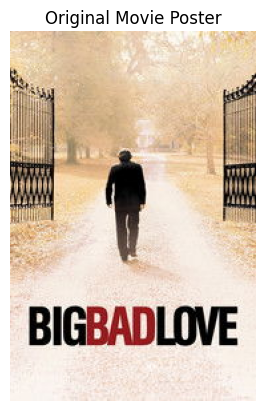

Image dimensions: 278x185 pixels (Height x Width)


In [ ]:
import os
from PIL import Image
import matplotlib.pyplot as plt

id = train_subset.iloc[42]['tmdbId']

# Define the image directory
IMAGE_DIR = "./datasets/posters/"

# Construct the image path
image_filename = f"{id}.jpg"
image_path = os.path.join(IMAGE_DIR, image_filename)


image = Image.open(image_path)

# Display the image
plt.imshow(image)
plt.title(f"Original Movie Poster")
plt.axis('off')
plt.show()

# Print its dimensions
print(f"Image dimensions: {image.size[1]}x{image.size[0]} pixels (Height x Width)")

**Exploratory Data Analysis**

Before building any classification model, it is critical to understand the distribution of your target labels. If 80% of our movies are Dramas and only 2% are Westerns, the model might simply learn to predict "Drama" every time and ignore "Western" completely.

We will deal with this later.

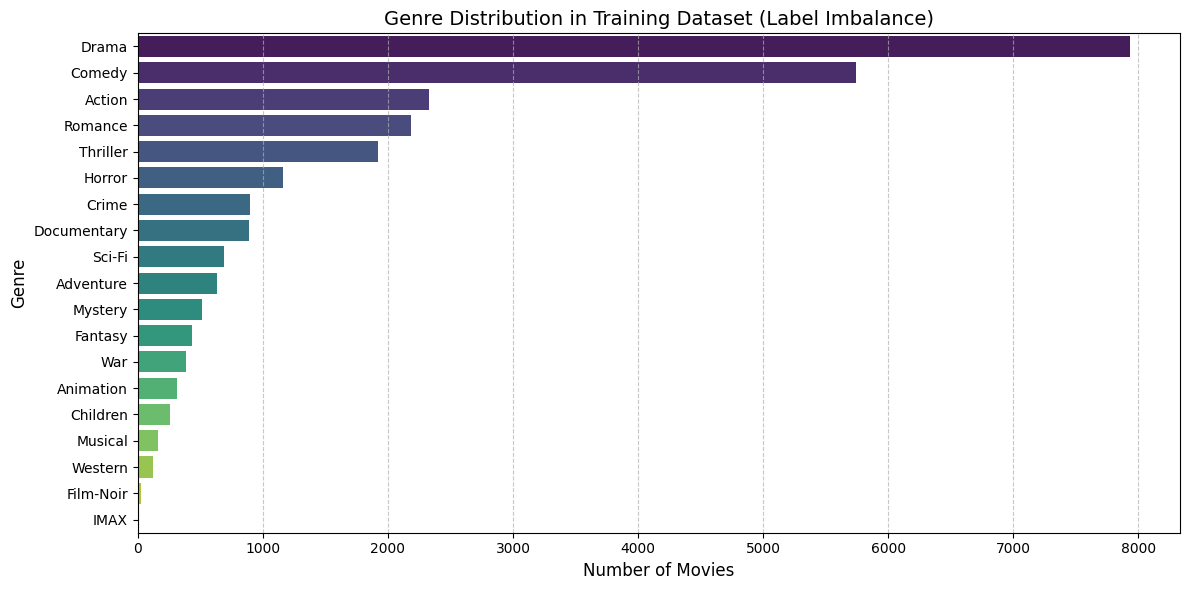

Top 3 Most Frequent Genres:
Drama     7936
Comedy    5743
Action    2325
dtype: int64

Bottom 3 Least Frequent Genres:
Western      121
Film-Noir     22
IMAX           8
dtype: int64


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
genre_columns = mlb.classes_

# Sum the occurrences of each genre
genre_counts = train_subset[genre_columns].sum().sort_values(ascending=False)

# Plotting the distribution
plt.figure(figsize=(12, 6))
sns.barplot(x=genre_counts.values, y=genre_counts.index, hue=genre_counts.index, palette="viridis", legend=False)
plt.title("Genre Distribution in Training Dataset (Label Imbalance)", fontsize=14)
plt.xlabel("Number of Movies", fontsize=12)
plt.ylabel("Genre", fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Print the top 3 and bottom 3 genres
print("Top 3 Most Frequent Genres:")
print(genre_counts.head(3))
print("\nBottom 3 Least Frequent Genres:")
print(genre_counts.tail(3))

CNNs (like ResNet) expect square inputs, so you **must** apply a transform to resize/crop them.
Since we are training from scratch, we will use a resolution of **128x128 pixels** to ensure the model trains reasonably fast and fits within memory constraints.

Let's package the posters into a ``MoviePosterDataset`` class.

In [ ]:
import os
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

class MoviePosterDataset(Dataset):
    def __init__(self, dataframe, image_dir, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.image_dir = image_dir
        self.transform = transform

        # Get the label columns directly from mlb.classes_
        # This ensures we always select only the genre columns by their names
        self_label_cols_ = list(mlb.classes_)
        self.label_cols = [col for col in self.dataframe.columns if col in self_label_cols_]

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):

        row = self.dataframe.iloc[idx]
        tmdb_id = row['tmdbId']

        image_path = os.path.join(self.image_dir, f"{tmdb_id}.jpg")
        image = Image.open(image_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        labels = torch.tensor(row[self.label_cols].values.astype("float32"), dtype=torch.float32)

        return image, labels


target_size = 128

poster_transform = transforms.Compose([
    transforms.Resize((target_size, target_size)),
    transforms.CenterCrop(target_size),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

In [ ]:
# Test the dataset
IMAGE_DIR = "./datasets/posters/"

train_dataset = MoviePosterDataset(train_subset, IMAGE_DIR, transform=poster_transform)

print("Dataset size:", len(train_dataset))

image, labels = train_dataset[0]

print("Image type:", type(image))
print("Image shape:", image.shape)
print("Labels type:", type(labels))
print("Labels shape:", labels.shape)
print("Labels:", labels)

Dataset size: 14630
Image type: <class 'torch.Tensor'>
Image shape: torch.Size([3, 128, 128])
Labels type: <class 'torch.Tensor'>
Labels shape: torch.Size([19])
Labels: tensor([0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0.])


In [ ]:
sample_idx = 0
row = train_subset.iloc[sample_idx]

print("Title:", row['title'])
print("Original genres string:", row['genres'])

image, labels = train_dataset[sample_idx]

active_genres = [mlb.classes_[i] for i, v in enumerate(labels.numpy()) if v == 1]
print("Decoded active genres:", active_genres)

Title: 7 Days in Havana (2012)
Original genres string: Drama
Decoded active genres: ['Drama']


In [ ]:
from sklearn.model_selection import train_test_split

# Split the Training Data into Train and Validation (80/20)
train_df, val_df = train_test_split(train_subset, test_size=0.2, random_state=42)

# Instantiate the Datasets
print("Initializing Datasets...")
train_dataset = MoviePosterDataset(dataframe=train_df, image_dir=IMAGE_DIR, transform=poster_transform)
val_dataset = MoviePosterDataset(dataframe=val_df, image_dir=IMAGE_DIR, transform=poster_transform)

# Use the ML-Small dataset as our Test Set!
test_dataset = MoviePosterDataset(dataframe=small_full, image_dir=IMAGE_DIR, transform=poster_transform)

Initializing Datasets...


You can save `train_df, val_df` to use in following parts without having to regerate them, using the pickle format.




In [ ]:
import pickle as pkl
pkl.dump(train_df, open("train_df.pkl", "wb"))
pkl.dump(val_df, open("val_df.pkl", "wb"))

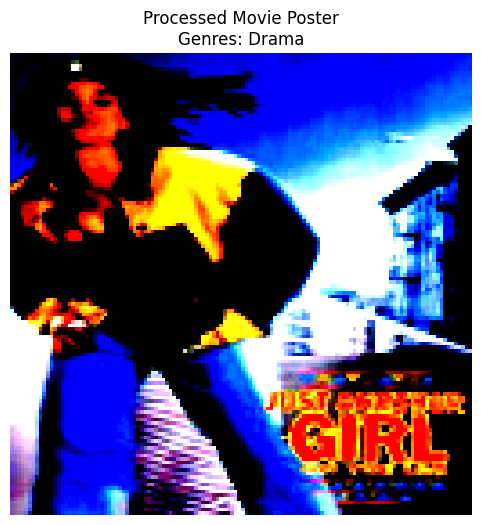

In [ ]:
import numpy as np

image, labels = train_dataset[42]
# Convert tensor to numpy array and move channels to the last dimension (H, W, C)
image = image.numpy().transpose((1, 2, 0))
# # Clip values to [0, 1] as some values might be slightly outside due to floating point operations
image = np.clip(image, 0, 1)

# Get the genre names corresponding to the '1's in the labels
# The label_cols from MoviePosterDataset stores the order of genres
label_cols = train_dataset.label_cols
active_genres = [genre for i, genre in enumerate(label_cols) if labels[i] == 1]
genres_str = ', '.join(active_genres) if active_genres else 'No genres listed'

# Display the image
plt.figure(figsize=(6, 6))
plt.imshow(image)
plt.title(f"Processed Movie Poster\nGenres: {genres_str}")
plt.axis('off')
plt.show()

In [ ]:
batch_size = 32

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Train Size: {len(train_dataset)} | Val Size: {len(val_dataset)} | Test (ML-Small) Size: {len(test_dataset)}")

print("For Training: ")
print(f"Number of Batches per Epoch: {len(train_loader)}")

sample_images, sample_labels = next(iter(train_loader))
print(f"Image Batch Shape: {sample_images.shape} -> [Batch, Channels, Height, Width]")
print(f"Label Batch Shape: {sample_labels.shape} -> [Batch, Num_Genres]")

Train Size: 11704 | Val Size: 2926 | Test (ML-Small) Size: 9617
For Training: 
Number of Batches per Epoch: 366
Image Batch Shape: torch.Size([32, 3, 128, 128]) -> [Batch, Channels, Height, Width]
Label Batch Shape: torch.Size([32, 19]) -> [Batch, Num_Genres]


### Custom CNN Architecture

A custom convolutional neural network is trained from scratch to predict movie genres from poster images.

Because each movie may belong to multiple genres simultaneously, the problem is formulated as **multi-label classification**. The network uses convolutional layers to learn visual features from the posters and produces one output logit per genre.

The learned representation is later used both for genre classification and as a candidate visual feature representation for the graph-based recommendation system.

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class CustomCNN(nn.Module):
    def __init__(self, num_classes):
        super(CustomCNN, self).__init__()

        # Convolutional feature extractor.
        # combination of nn.Conv2d, nn.ReLU, and nn.MaxPool2d.
        self.features = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )


        self.flatten_dim = 256 * 8 * 8

        # Classification head. nn.Linear layers and
        # nn.Dropout to prevent overfitting. 
        self.fc1 = nn.Linear(self.flatten_dim, 512)
        self.dropout = nn.Dropout(0.4)
        self.fc2 = nn.Linear(512, num_classes)

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, start_dim=1)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)

        return x

    def extract_embeddings(self, x):
        """
        Helper function for Task 3:
        Runs the forward pass up to the penultimate layer and returns the dense feature vector.
        """
        # Implementation to return the output of your
        # final hidden layer BEFORE it hits the final classification layer.

        x = self.features(x)
        x = torch.flatten(x, start_dim=1)
        x = F.relu(self.fc1(x))

        return x

In [ ]:
# Initialization of the model
num_genres = len(mlb.classes_)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

cv_model = CustomCNN(num_classes=num_genres).to(device)
print(f"Model initialized on: {device}")

Model initialized on: cuda


### CNN Architecture and Training

A convolutional neural network is used to learn visual representations directly from movie posters.

The model is trained as a **multi-label classifier**, predicting the genres associated with each movie. Since multiple genres may be active simultaneously, the output layer produces independent predictions for each genre.

After training, the learned intermediate representation is extracted and used as the **visual feature vector** for each movie in the recommendation experiments.

Our dataset is heavily imbalanced. If we train normally, the model will just learn to predict "Drama" and "Comedy" for everything.

To fix this, we will calculate the **Positive Weight (`pos_weight`)** for each genre. This tells the loss function to assign a higher penalty when the model makes a mistake on a rare genre.
The formula is: `pos_weight = (Total Samples - Positive Samples) / Positive Samples`

In [ ]:
#number of positive occurrences for each genre in the training set
pos_counts = train_df[genre_columns].sum().values
total_samples = len(train_df)

# pos_weight: (negatives / positives)
pos_weights = (total_samples - pos_counts) / pos_counts
#square root to dampen extreme values
smoothed_weights = np.sqrt(pos_weights)

#Convertion to PyTorch tensor and move to the device (GPU/CPU)
pos_weight_tensor = torch.tensor(smoothed_weights, dtype=torch.float32).to(device)

print("Calculated pos_weight for the first 5 genres:")
for i in range(5):
    print(f"{genre_columns[i]}: {pos_weight_tensor[i].item():.2f}")

In [ ]:
import torch.optim as optim
from tqdm import tqdm

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight_tensor)
optimizer = optim.Adam(cv_model.parameters(), lr=1e-3)


epochs = 6 

train_losses = []
val_losses = []

for epoch in range(epochs):
    # --- TRAINING PHASE ---
    cv_model.train()
    running_loss = 0.0
    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]")

    for images, labels in progress_bar:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = cv_model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        # Loss update
        running_loss += loss.item() * images.size(0)
        progress_bar.set_postfix({'batch_loss': loss.item()})


    train_loss = running_loss / len(train_dataset)
    train_losses.append(train_loss) # Store for plotting

    # --- VALIDATION PHASE ---
    cv_model.eval()
    val_loss = 0.0

    # torch.no_grad() prevents PyTorch from storing gradients, saving memory during eval
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = cv_model(images)
            loss = criterion(outputs, labels)

            # Loss update
            val_loss += loss.item() * images.size(0)

    val_loss = val_loss / len(val_dataset)
    val_losses.append(val_loss) # Store for plotting

    print(f"End of Epoch {epoch+1} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

print("Training complete!")

Initially we had used 10 epochs but we noticed that after the 6th epoch the validation loss started to increase which was an indicator of overfitting. therefore we re-trained with 6 epochs.

In [ ]:
# --- VISUALIZE LOSS CURVES ---
plt.figure(figsize=(10, 5))
plt.plot(range(1, epochs+1), train_losses, label='Training Loss', marker='o', color='blue')
plt.plot(range(1, epochs+1), val_losses, label='Validation Loss', marker='o', color='orange')
plt.title('Training and Validation Loss Over Epochs', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.xticks(range(1, epochs+1))
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
torch.save(cv_model.state_dict(), "custom_cnn.pth")

we saved the model so we didn't have to re-run the training again and again every time we wanted to work on the notebook.

### Model Evaluation & Qualitative Analysis

The Custom CNN is evaluated using metrics appropriate for **multi-label classification**.

Exact-match accuracy is overly restrictive in this setting because a prediction may correctly identify some, but not all, of a movie's genres. Therefore, the evaluation focuses primarily on **F1-score** and **ROC-AUC**, complemented by qualitative inspection of individual poster predictions.

This analysis provides both a quantitative assessment of classification performance and insight into which genres can be inferred effectively from visual information.

**1. Quantitative Metrics**
Write an evaluation loop (using a separate validation/test set) to calculate the following:
* **Sigmoid Activation:** Pass your model's raw output logits through a `torch.sigmoid()` function to convert them into probabilities (0.0 to 1.0).
* **Thresholding:** Convert those probabilities into binary predictions (0 or 1) using a threshold (e.g., `0.5`).
* **Macro F1-Score:** Calculate the F1-score for each genre independently, then take the unweighted average.
* **Micro F1-Score:** Calculate the F1-score globally by counting the total true positives, false negatives, and false positives across all classes.

In [ ]:
cv_model = CustomCNN(num_classes=num_genres).to(device)
cv_model.load_state_dict(torch.load("custom_cnn", map_location=device))
cv_model.eval()
print("Saved Custom CNN model loaded successfully.")

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, roc_auc_score

# 1. Quantitative Evaluation
cv_model.eval()

all_targets = []
all_predictions = []

print("Evaluating model on the Test Set (ML-Small)...")

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = cv_model(images)

        probabilities = torch.sigmoid(outputs).cpu().numpy()
        targets = labels.cpu().numpy()

        all_predictions.append(probabilities)
        all_targets.append(targets)

all_predictions = np.vstack(all_predictions)
all_targets = np.vstack(all_targets)

binary_predictions = (all_predictions >= 0.5).astype(int)

macro_f1 = f1_score(all_targets, binary_predictions, average='macro', zero_division=0)
micro_f1 = f1_score(all_targets, binary_predictions, average='micro', zero_division=0)
roc_auc = roc_auc_score(all_targets, all_predictions, average='macro')

# --- VISUALIZE QUANTITATIVE METRICS ---
metrics_dict = {'Macro F1': macro_f1, 'Micro F1': micro_f1, 'ROC-AUC': roc_auc}

plt.figure(figsize=(8, 5))
bars = plt.bar(metrics_dict.keys(), metrics_dict.values(), color=['#87CEEB', '#98FB98', '#FA8072'])
plt.ylim(0, 1.1)
plt.title('Test Set Evaluation Metrics', fontsize=14)
plt.ylabel('Score', fontsize=12)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.02, f'{yval:.4f}',
             ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


**2. Qualitative Analysis**
Visualize your model's predictions to see if they make logical sense.
* Write a function to display a grid of 5 random movie posters from your dataset.
* Above each poster, print the **True Genres** and the **Predicted Genres** (any genre where the predicted probability was > 0.5).

In [ ]:
# ==========================================
# 2. Qualitative  (Visual Grid)
# ==========================================
def imshow_denormalized(img):
    # img = img / 2 + 0.5
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])

    npimg = img.numpy().transpose((1, 2, 0))
    npimg = std * npimg + mean
    npimg = np.clip(npimg, 0, 1)
    plt.imshow(npimg)

images, labels = next(iter(test_loader))

with torch.no_grad():
    outputs = cv_model(images.to(device))
    probs = torch.sigmoid(outputs)
    preds = (probs >= 0.5).int().cpu()

fig, axes = plt.subplots(1, 5, figsize=(20, 5))
genre_names = mlb.classes_

for i in range(5):
    ax = axes[i]

    true_genres = [genre_names[j] for j in range(len(genre_names)) if labels[i][j] == 1]
    pred_genres = [genre_names[j] for j in range(len(genre_names)) if preds[i][j] == 1]

    # ==========================================
    # --- VISUALIZATION ---
    # ==========================================
    plt.sca(ax)
    imshow_denormalized(images[i])
    ax.axis('off')

    title_text = f"True: {', '.join(true_genres)}\nPred: {', '.join(pred_genres) if pred_genres else 'None'}"
    color = 'green' if set(true_genres) == set(pred_genres) else 'black'
    ax.set_title(title_text, fontsize=10, wrap=True, color=color)

plt.tight_layout()
plt.show()

### Evaluation Analysis

The following observations summarize the behavior of the Custom CNN, including the suitability of different evaluation metrics, the effect of the classification threshold, class imbalance, and the visual ambiguity of movie genres.

1. Standard "exact match accuracy" is a poor metric for this specific task because for some movies that belong in more than one genres, if the prediction doesn't match the full label set completely it is counted as wrong. For example, if a movie is Action, Comedy and Sci-fi and the model predicts Action and Comedy it is counted as completely wrong. 
If we predict every movie is a "Drama" and "Comedy", which are the most common genres as we calculated before, the micro-F1 score, which counts the total true positives, false negatives and false positives across all classes, will perform relatively okay since it will collect the true positives from these genres. However, the macro-F1 score, that calculates the F1 score for each genre independently, will be a lot worse because the model will fail in all other genres.


2. If we lower the threshold from 0.5 to 0.3 we expect that Precision will decrease and Recall will increase since with a lower threshold it becomes "easier" for the model to assign each genre as present. Therefore it will detect more true genres that it previously missed, so we will have less false negatives and hence, recall is increased. At the same time the number of false positives will increase which decreases precision.
    

In [ ]:
from sklearn.metrics import f1_score
import pandas as pd

per_class_f1 = f1_score(all_targets, binary_predictions, average=None, zero_division=0)

per_class_f1_df = pd.DataFrame({
    'Genre': mlb.classes_,
    'F1 Score': per_class_f1
}).sort_values(by='F1 Score', ascending=False)

display(per_class_f1_df)

print("Best performing genres:")
display(per_class_f1_df.head(5))

print("Worst performing genres:")
display(per_class_f1_df.tail(5))


3. Based on the above calculated F1 scores the model performed best on Drama, Comedy, Thriller, Animation and Action. It struggled with Documentary, Film-Noir, Fantasy, Crime, IMAX, Mystery, Musical, War and Western. We conclude that the model scores higher in the most frequent categories whereas it has a lower F1-score in the rare ones.

4.Based on the visual eye test, Animation seems visually easy for a CNN to learn, because animated posters usually contain bright colors, cartoon characters, and a highly stylized design. On the other hand, Drama seems visually ambiguous, because drama posters often rely on generic visual elements such as faces, neutral backgrounds, and realistic scenes, which overlap heavily with other genres like Romance and Comedy.

### Transfer Learning with Pre-trained ResNet

To compare the custom CNN with a transfer-learning approach, a ResNet model pretrained on ImageNet is adapted to the multi-label movie genre classification task.

The final classification layer is modified to match the number of movie genres and the network is fine-tuned on the training set. Performance is evaluated on the ML-Small test set using **Macro F1, Micro F1, and ROC-AUC**, enabling a direct comparison between representations learned from scratch and features transferred from a pretrained visual model.

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models

# ==========================================
# Pretrained ResNet Initialization & Fine-Tuning
# ==========================================

# pre-trained ResNet model
resnet_model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# 2. Modify the final classification head
num_ftrs = resnet_model.fc.in_features

# Freezing all pretrained layers
for param in resnet_model.parameters():
    param.requires_grad = False

resnet_model.fc = nn.Linear(num_ftrs, num_genres)
resnet_model = resnet_model.to(device)

# 3. Optimizer and Loss
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight_tensor)
optimizer = optim.Adam(filter(lambda p: p.requires_grad, resnet_model.parameters()), lr=1e-4)

epochs_resnet = 15

train_losses_res = []
val_losses_res = []

print("Training ResNet classifier head...")
for epoch in range(epochs_resnet):
    # --- TRAINING PHASE ---
    resnet_model.train()
    running_loss = 0.0
    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs_resnet} [Train]")

    for images, labels in progress_bar:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = resnet_model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        progress_bar.set_postfix({'batch_loss': loss.item()})

    train_loss = running_loss / len(train_dataset)
    train_losses_res.append(train_loss)

    # --- VALIDATION PHASE ---
    resnet_model.eval()
    val_loss = 0.0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = resnet_model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)

    val_loss = val_loss / len(val_dataset)
    val_losses_res.append(val_loss)

    print(f"End of Epoch {epoch+1} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

We used the pre-trained ResNet18 initialized with ImageNet weights. To adapt the model to our task, we replaced the final fully connected layer of ResNet with a new classification head whose output matches the number of movie genres in our dataset.At first, we tried to fine-tune the entire ResNet model, but this led to overfitting, as the training loss dropped very quickly while the validation loss started to increase. Therefore we decided to freeze all pre-trained previous layers and we trained only the final fully connected layer.

This means that we used the ResNet as a feature extractor, while only the last classification layer learned to classify those features to the movie genres which produced more stable training behavior and better validation performance than full fine-tuning.

In [ ]:
# --- VISUALIZE RESNET LOSS CURVES ---
plt.figure(figsize=(10, 5))
plt.plot(range(1, epochs_resnet+1), train_losses_res, label='Training Loss', marker='o', color='blue')
plt.plot(range(1, epochs_resnet+1), val_losses_res, label='Validation Loss', marker='o', color='orange')
plt.title('ResNet Training and Validation Loss Over Epochs', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.xticks(range(1, epochs_resnet+1))
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, roc_auc_score

# 1. Quantitative Evaluation
resnet_model.eval()
all_targets_res = []
all_predictions_res = []

print("Evaluating model on the Test Set (ML-Small)...")
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = resnet_model(images)

        probabilities = torch.sigmoid(outputs).cpu().numpy()
        targets = labels.cpu().numpy()

        all_predictions_res.append(probabilities)
        all_targets_res.append(targets)

all_predictions_res = np.vstack(all_predictions_res)
all_targets_res = np.vstack(all_targets_res)

binary_predictions_res = (all_predictions_res >= 0.5).astype(int)

macro_f1_res = f1_score(all_targets_res, binary_predictions_res, average='macro', zero_division=0)
micro_f1_res = f1_score(all_targets_res, binary_predictions_res, average='micro', zero_division=0)
roc_auc_res = roc_auc_score(all_targets_res, all_predictions_res, average='macro')

# --- VISUALIZE QUANTITATIVE METRICS ---
metrics_dict_res = {'Macro F1': macro_f1_res, 'Micro F1': micro_f1_res, 'ROC-AUC': roc_auc_res}

plt.figure(figsize=(8, 5))
bars = plt.bar(metrics_dict_res.keys(), metrics_dict_res.values(), color=['#87CEEB', '#98FB98', '#FA8072'])
plt.ylim(0, 1.1)
plt.title('Test Set Evaluation Metrics', fontsize=14)
plt.ylabel('Score', fontsize=12)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.02, f'{yval:.4f}',
             ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Custom CNN vs. Pre-trained ResNet

The following analysis compares the custom CNN trained from scratch with the ImageNet-pretrained ResNet model, focusing on classification performance, generalization, and the effect of transfer learning on visual representation quality.

1. The Pre-trained ResNet performed better than the custom CNN in both evaluation metrics. More specifically, the macro F1 improved from 0.12 to 0.2146 which is an increase of 0.0946 and the ROC-AUC improved from 0.4993 to 0.7038 which is an increase of 0.2045

2. The Pre-trained Resnet converged faster and more smoothly than the Custom CNN. Its training loss both decreased steadily especially after freezing all the layers except the last fully connected layer. On the other hand, the custom CNN also improved over time but its learning was slower. Its training and validation losses stayed relatively close, so there was no severe overfitting, although the validation curve showed small fluctuations. 

3. The pre-trained ResNet performs better because it has already learned strong and general visual feautures from the large ImageNet dataset, such as edges, textures and shapes. As a result, when we train it on the movie poster dataset, it just adapts these features to the new task instead of learning everything from the beginning. On the other hand, the custom CNN starts with random weights and must learn all visual representations directly from the dataset movie posters. Therefore the custom CNN is expected to have weaker generalization. ResNet also has a stronger architecture because its residual connections allow the dataset information and the gradients pass more easily through the network making training more stable.

### Extraction of Visual Movie Embeddings

Following the comparison between the Custom CNN and the pre-trained ResNet, the best-performing visual model is selected for feature extraction.

Rather than using the final genre-classification logits, movie posters are passed through the selected model and representations are extracted from its penultimate layer. These dense vectors capture visual information learned from the genre-classification task and are subsequently used as movie-node features in the graph-based recommendation experiments.

The embedding order is kept aligned with the movie dataframe so that each visual representation corresponds to the correct movie node.

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from tqdm import tqdm

best_vision_model = resnet_model

# DataLoader (CRITICAL: shuffle MUST be False to match embeddings to movieIds!)
inference_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2
)

#chosen model to evaluation mode
best_vision_model.eval()
all_embeddings = []

print(f"Extracting embeddings for {len(test_dataset)} movies...")

# Loop over the images in `inference_loader`.
# Extraction the corresponding embeddings.
# Moving the resulting embeddings back to `.cpu()` and appending them to the `all_embeddings` list.

# --- YOUR EXTRACTION LOOP HERE ---
feature_extractor = nn.Sequential(*list(best_vision_model.children())[:-1]).to(device)

with torch.no_grad():
    for images, _ in tqdm(inference_loader):
        images = images.to(device)

        embeddings = feature_extractor(images)   # [batch_size, 512, 1, 1]
        embeddings = torch.flatten(embeddings, 1)  # [batch_size, 512]

        all_embeddings.append(embeddings.cpu())

# ---------------------------------

# Concatenating all batches into a single large tensor
final_visual_embeddings = torch.cat(all_embeddings, dim=0)
print(f"Extracted Embeddings Shape: {final_visual_embeddings.shape} -> [Num_Movies, Embedding_Dim]")

# ==========================================
# --- SAVING BOILERPLATE ---
# ==========================================
save_dict = {
    'movie_ids': torch.tensor(small_full['movieId'].values),
    'embeddings': final_visual_embeddings
}

torch.save(save_dict, 'datasets/cv_embeddings.pt')
print("Visual embeddings successfully saved to 'datasets/cv_embeddings.pt'!")

## Part 2 — Textual Representation Learning

Movie plot summaries are used as the textual modality of the recommendation pipeline.

The text is preprocessed and encoded to learn representations that capture semantic information about each movie. A text classification task is used to train the representation model, after which the learned embeddings are extracted and used as **textual movie-node features**.

These features are later evaluated alongside the visual and multimodal representations within the graph-based recommendation framework.

### **Text Preprocessing & Data Loading**
Unlike images, neural networks cannot process raw text. We must convert the words into numerical tokens. Below, we provide the pipeline to:
1. Clean and tokenize the text.
2. Build a Vocabulary based solely on the training set (to avoid data leakage).
3. Convert summaries into padded numerical tensors.

In [51]:
import os

dataset_dir = "./datasets"

if os.path.exists(dataset_dir):
    print(f"Dataset folder found at: {dataset_dir}")
    print("Files:", os.listdir(dataset_dir)[:10])
else:
    print(f"Dataset folder not found at: {dataset_dir}")

Dataset folder found at: ./datasets
Files: ['train_metadata_full.csv', 'cv_embeddings.pt', 'ml_small_metadata_full.csv', 'pretrained_nlp_embeddings.pt', 'ml-latest-small', 'ml-25m', 'posters', 'nlp_embeddings.pt']


In JupyterLab, where we run the code, the datasets folder is already available locally, so no unzip step is required.

In [52]:
import pickle as pkl

# load pre-saved pickled dataframes, if needed
train_df = pkl.load(open('train_df.pkl', 'rb'))
val_df = pkl.load(open('val_df.pkl', 'rb'))

A tokenizer is essentially the "translator" that turns a raw blob of text into a format a machine can actually digest.

Complete the simple tokenizer, as instructed below.

In [ ]:
import pandas as pd
import re
from collections import Counter
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence

# Simple Tokenizer, returns a list of strings
def tokenize(text):
    """Lowercases, removes punctuation, and splits by whitespace."""
    # Convertion of the input text to a lowercase string.
    # 2. Using regex to remove any character that isn't a letter, number, or whitespace.
    # 3. Split cleaned string into a list of individual words (tokens).

    # --- YOUR CODE HERE ---
    text = "" if pd.isna(text) else str(text).lower()
    text = re.sub(r"[^a-z0-9\s]", "", text)
    tokens = text.split()
    return tokens
    # ----------------------


# Build Vocabulary from Training Set ONLY
print("Building vocabulary...")
all_tokens = []
for plot in train_df['overview']:
    all_tokens.extend(tokenize(plot))

Building vocabulary...


We need to build a mapping of the words within the plot summaries. We select our vocabulary to contain the top 10,000 most frequent words and map them to unique IDs. It reserves 0 for padding and 1 for unknown words (the rare ones we excluded). Raw text needs to be converted into fixed-length numerical vectors (here, set to 150 tokens), truncating long sequences and padding short ones to ensure uniform input for the model.

In [ ]:
# Kept top 10,000 most common words, reserve 0 for <PAD> and 1 for <UNK>

max_vocab_size = 10000
vocab_counts = Counter(all_tokens)
vocab = {word: idx + 2 for idx, (word, _) in enumerate(vocab_counts.most_common(max_vocab_size))}
vocab['<PAD>'] = 0
vocab['<UNK>'] = 1

def text_to_tensor(text, vocab, max_len=150):
    """Converts a text string to a padded tensor of token IDs."""
    tokens = tokenize(text)
    token_ids = [vocab.get(word, vocab['<UNK>']) for word in tokens]

    # Truncate if too long
    if len(token_ids) > max_len:
        token_ids = token_ids[:max_len]

    # Pad if too short
    pad_len = max_len - len(token_ids)
    token_ids = token_ids + [vocab['<PAD>']] * pad_len

    return torch.tensor(token_ids, dtype=torch.long)

In [55]:
import torch
sample_text = train_df['overview'].iloc[0]
sample_tensor = text_to_tensor(sample_text, vocab)

print("Original text:", sample_text[:200])
print("Tensor shape:", sample_tensor.shape)
print("First 20 token IDs:", sample_tensor[:20])

Original text: A young girl's brother comes home from the army, and brings an army buddy with him. The three of them go out that night to celebrate, and after much drinking has been done, the brother's friend rapes 
Tensor shape: torch.Size([150])
First 20 token IDs: tensor([   3,   32,  277,  150,  148,   82,   21,    2,  377,    5,  507,   14,
         377, 1875,   10,   30,    2,   97,    6,   49])


And we will build a pytorch dataset like before.

In [56]:
class MoviePlotDataset(Dataset):
    def __init__(self, dataframe, vocab):
        self.dataframe = dataframe.reset_index(drop=True)
        self.vocab = vocab
        self.label_cols = mlb.classes_.tolist()

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        plot_text = self.dataframe.loc[idx, 'overview']
        text_tensor = text_to_tensor(plot_text, self.vocab)

        # Extract labels
        labels = self.dataframe.loc[idx, self.label_cols].values.astype(float)
        labels = torch.tensor(labels, dtype=torch.float32)

        return text_tensor, labels

In [ ]:
import pandas as pd

small_full = pd.read_csv('./datasets/ml_small_metadata_full.csv')
print("small_full loaded successfully.")
print(small_full.shape)

# Adding the 19 multi-hot genre label columns using the already-fitted mlb
# We convert the raw genres string into 19 multi-hot genre columns,
# The evaluation pipeline expects numeric multi-hot genre labels rather than the raw 'genres' text column.

small_labels = pd.DataFrame(

    mlb.transform(small_full['genres'].str.split('|')),

    columns=mlb.classes_,

    index=small_full.index

)

small_full = pd.concat([small_full, small_labels], axis=1)

print("After adding genre labels:", small_full.shape)

small_full loaded successfully.
(9617, 6)
After adding genre labels: (9617, 25)


/home/lamarantidi/.local/lib/python3.9/site-packages/sklearn/preprocessing/_label.py:909: UserWarning: unknown class(es) ['(no genres listed)'] will be ignored
  warnings.warn(


In [58]:
print("Initializing NLP Datasets...")
nlp_train_dataset = MoviePlotDataset(train_df, vocab)
nlp_val_dataset = MoviePlotDataset(val_df, vocab)
nlp_test_dataset = MoviePlotDataset(small_full, vocab)

Initializing NLP Datasets...


In [59]:
batch_size = 32
nlp_train_loader = DataLoader(nlp_train_dataset, batch_size=batch_size, shuffle=True)
nlp_val_loader = DataLoader(nlp_val_dataset, batch_size=batch_size, shuffle=False)
nlp_test_loader = DataLoader(nlp_test_dataset, batch_size=batch_size, shuffle=False)

# Test the dataloader
print("For training...")
sample_texts, sample_labels = next(iter(nlp_train_loader))
print(f"Text Batch Shape: {sample_texts.shape} -> [Batch, Sequence_Length]")
print(f"Label Batch Shape: {sample_labels.shape} -> [Batch, Num_Genres]")

For training...
Text Batch Shape: torch.Size([32, 150]) -> [Batch, Sequence_Length]
Label Batch Shape: torch.Size([32, 19]) -> [Batch, Num_Genres]


### Recurrent Text Model with Self-Attention

A recurrent neural network is used to learn semantic representations from movie plot summaries.

Rather than relying only on the final hidden state, a **self-attention mechanism** combines information from all hidden states in the sequence. Given the recurrent hidden states

$H = [h_1, h_2, ..., h_T]$:

attention scores are computed for each position and normalized into attention weights. The resulting context vector is a weighted combination of the hidden states:

$c = \sum_{t=1}^{T} \alpha_t h_t$

This allows the model to emphasize the parts of a plot summary that are most informative for genre classification. The resulting context vector is used both for classification and as the learned textual representation of the movie.



In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class CustomTextClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes):
        super(CustomTextClassifier, self).__init__()

        # 1. Embedding layer: map vocab_size to embed_dim (don't forget padding_idx=0)
        # 2. RNN layer: set batch_first=True
        # 3. Attention Projection: a Linear layer mapping hidden_dim to a single score (1)
        # 4. Classifier Head: a Linear layer mapping hidden_dim to num_classes

        # --- YOUR LAYERS HERE ---
        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=embed_dim,
            padding_idx=0
        )

        self.rnn = nn.GRU(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            batch_first=True
        )

        self.attention_proj = nn.Linear(hidden_dim, 1)

        self.fc = nn.Linear(hidden_dim, num_classes)

        self.dropout = nn.Dropout(0.3)
        # ------------------------


    def forward(self, x):

        # 1. Pass input through the embedding layer.
        # 2. Pass embeddings through the RNN. Get all hidden states 'H'.
        # 3. Calculate energy scores 'e'
        # 4. Calculate attention weights 'alpha'.
        # 5. Calculate the context vector 'c'.
        # 6. Pass the context vector through the final classifier to get logits.

        # --- YOUR FORWARD PASS HERE ---
        embedded = self.embedding(x)                    # [B, T] -> [B, T, E]
        H, _ = self.rnn(embedded)                       # [B, T, E] -> [B, T, H]

        e = self.attention_proj(H).squeeze(-1)         # [B, T, H] -> [B, T, 1] -> [B, T]
        alpha = F.softmax(e, dim=1)                    # [B, T]

        c = torch.sum(H * alpha.unsqueeze(-1), dim=1)  # [B, T, H] * [B, T, 1] -> [B, H]
        c = self.dropout(c)

        logits = self.fc(c)                            # [B, H] -> [B, C]

        return logits
        # ------------------------------



    def extract_embeddings(self, x):
        """Returns the final context vector 'c' BEFORE the classification head."""

        # --- YOUR EXTRACTION HERE ---
        embedded = self.embedding(x)
        H, _ = self.rnn(embedded)

        e = self.attention_proj(H).squeeze(-1)
        alpha = F.softmax(e, dim=1)

        c = torch.sum(H * alpha.unsqueeze(-1), dim=1)

        return c
        # ----------------------------

In [61]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Model will be initialized in {device}.\n")

vocab_size = len(vocab)
embed_dim = 128
hidden_dim = 256
num_classes = len(nlp_train_dataset.label_cols)

nlp_model = CustomTextClassifier(vocab_size, embed_dim, hidden_dim, num_classes).to(device)
print(nlp_model)

Model will be initialized in cuda.

CustomTextClassifier(
  (embedding): Embedding(10002, 128, padding_idx=0)
  (rnn): GRU(128, 256, batch_first=True)
  (attention_proj): Linear(in_features=256, out_features=1, bias=True)
  (fc): Linear(in_features=256, out_features=19, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
)


### Text Model Training

The textual representation model is trained using movie plot summaries as input.

The model learns features that capture semantic information from the plot text while performing the associated classification task. After training, the learned representations are extracted and stored as movie embeddings for the subsequent recommendation experiments.

In [62]:
import torch
import numpy as np

# Recompute pos_weight from the training dataframe
genre_columns = nlp_train_dataset.label_cols

pos_counts = train_df[genre_columns].sum().values
total_samples = len(train_df)

pos_weights = (total_samples - pos_counts) / pos_counts
smoothed_weights = np.sqrt(pos_weights)

pos_weight_tensor = torch.tensor(smoothed_weights, dtype=torch.float32).to(device)

print("Calculated pos_weight for the first 5 genres:")
for i in range(min(5, len(genre_columns))):
    print(f"{genre_columns[i]}: {pos_weight_tensor[i].item():.2f}")

Calculated pos_weight for the first 5 genres:
Action: 2.30
Adventure: 4.73
Animation: 6.80
Children: 7.70
Comedy: 1.25


Epoch 1/10 [Train]: 100%|███| 366/366 [00:08<00:00, 44.29it/s, batch_loss=0.478]


Epoch 1/10 - Train Loss: 0.5603, Val Loss: 0.5184


Epoch 2/10 [Train]: 100%|███| 366/366 [00:08<00:00, 43.23it/s, batch_loss=0.663]


Epoch 2/10 - Train Loss: 0.5108, Val Loss: 0.5115


Epoch 3/10 [Train]: 100%|███| 366/366 [00:08<00:00, 42.40it/s, batch_loss=0.475]


...

Epoch 8/10 - Train Loss: 0.4635, Val Loss: 0.4823


Epoch 9/10 [Train]: 100%|███| 366/366 [00:08<00:00, 42.90it/s, batch_loss=0.503]


Epoch 9/10 - Train Loss: 0.4546, Val Loss: 0.4771


Epoch 10/10 [Train]: 100%|██| 366/366 [00:08<00:00, 43.43it/s, batch_loss=0.459]


Epoch 10/10 - Train Loss: 0.4461, Val Loss: 0.4725
Best model saved from epoch 10 with val loss 0.4725


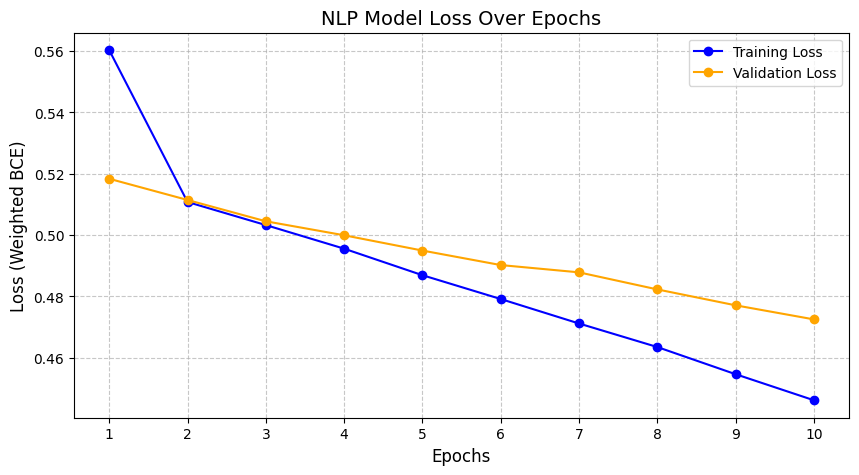

In [ ]:
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from tqdm import tqdm

# --- 1. SETUP ---
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight_tensor)
optimizer = optim.Adam(nlp_model.parameters(), lr=1e-4)

epochs = 10
train_losses = []
val_losses = []

best_val_loss = float('inf')
best_epoch = -1

# --- 2. TRAINING & VALIDATION LOOP ---
for epoch in range(epochs):
    # --- TRAINING PHASE ---
    nlp_model.train()
    running_train_loss = 0.0

    progress_bar = tqdm(nlp_train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]")

    for texts, labels in progress_bar:
        texts, labels = texts.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = nlp_model(texts)
        loss = criterion(outputs, labels)
        loss.backward()

        # Optional: Use gradient clipping to prevent exploding gradients
        torch.nn.utils.clip_grad_norm_(nlp_model.parameters(), max_norm=1.0)

        optimizer.step()

        running_train_loss += loss.item() * texts.size(0)
        progress_bar.set_postfix({'batch_loss': loss.item()})

    train_loss = running_train_loss / len(nlp_train_dataset)

    # --- VALIDATION PHASE ---
    nlp_model.eval()
    running_val_loss = 0.0

    with torch.no_grad():
        for texts, labels in nlp_val_loader:
            texts, labels = texts.to(device), labels.to(device)

            outputs = nlp_model(texts)
            loss = criterion(outputs, labels)

            running_val_loss += loss.item() * texts.size(0)

    val_loss = running_val_loss / len(nlp_val_dataset)

    # Save average losses for plotting
    train_losses.append(train_loss)
    val_losses.append(val_loss)

    # Save best model checkpoint
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch = epoch + 1
        torch.save(nlp_model.state_dict(), "nlp_model_task2_best.pth")

    print(f"Epoch {epoch+1}/{epochs} - Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

print(f"Best model saved from epoch {best_epoch} with val loss {best_val_loss:.4f}")

# ==========================================
# --- VISUALIZATION LOSS CURVES ---
# ==========================================
plt.figure(figsize=(10, 5))
plt.plot(range(1, epochs+1), train_losses, label='Training Loss', marker='o', color='blue')
plt.plot(range(1, epochs+1), val_losses, label='Validation Loss', marker='o', color='orange')
plt.title('NLP Model Loss Over Epochs', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss (Weighted BCE)', fontsize=12)
plt.xticks(range(1, epochs+1))
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [29]:
torch.save(nlp_model.state_dict(), "nlp_model_task2_best.pth")
print("NLP model saved successfully.")

NLP model saved successfully.


In [63]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

vocab_size = len(vocab)
embed_dim = 128
hidden_dim = 256
num_classes = len(nlp_train_dataset.label_cols)

nlp_model = CustomTextClassifier(vocab_size, embed_dim, hidden_dim, num_classes).to(device)
nlp_model.load_state_dict(torch.load("nlp_model_task2_best.pth", map_location=device))
nlp_model.eval()

print("Saved NLP model loaded successfully.")

Saved NLP model loaded successfully.


In [64]:
# --- 3. EVALUATION N TEST SET (ML-Small) ---
import torch
import numpy as np
from sklearn.metrics import f1_score, roc_auc_score

print("\nEvaluating on Test Set...")

nlp_model.load_state_dict(torch.load("nlp_model_task2_best.pth", map_location=device))
nlp_model.eval()

all_targets = []
all_predictions = []
all_probabilities = []

with torch.no_grad():
    for texts, labels in nlp_test_loader:
        texts = texts.to(device)

        outputs = nlp_model(texts)
        probabilities = torch.sigmoid(outputs).cpu().numpy()
        predictions = (probabilities >= 0.5).astype(np.int64)

        targets = labels.cpu().numpy()
        targets = (targets > 0.5).astype(np.int64)

        all_probabilities.append(probabilities)
        all_predictions.append(predictions)
        all_targets.append(targets)

all_probabilities = np.vstack(all_probabilities).astype(np.float32)
all_predictions = np.vstack(all_predictions).astype(np.int64)
all_targets = np.vstack(all_targets).astype(np.int64)

print("all_targets shape:", all_targets.shape)
print("all_predictions shape:", all_predictions.shape)
print("Unique targets:", np.unique(all_targets))
print("Unique preds:", np.unique(all_predictions))

macro_f1 = f1_score(all_targets, all_predictions, average='macro', zero_division=0)
micro_f1 = f1_score(all_targets, all_predictions, average='micro', zero_division=0)
roc_auc = roc_auc_score(all_targets, all_probabilities, average='macro')

print(f"Test Macro F1-Score: {macro_f1:.4f}")
print(f"Test Micro F1-Score: {micro_f1:.4f}")
print(f"Test ROC-AUC Score: {roc_auc:.4f}")


Evaluating on Test Set...
all_targets shape: (9617, 19)
all_predictions shape: (9617, 19)
Unique targets: [0 1]
Unique preds: [0 1]
Test Macro F1-Score: 0.1577
Test Micro F1-Score: 0.3407
Test ROC-AUC Score: 0.6702


In [65]:
print(nlp_test_dataset.dataframe.shape)
print(nlp_test_dataset.label_cols)
print(nlp_test_dataset.dataframe[nlp_test_dataset.label_cols].head())

(9617, 25)
['Action', 'Adventure', 'Animation', 'Children', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror', 'IMAX', 'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western']
   Action  Adventure  Animation  Children  Comedy  Crime  Documentary  Drama  \
0       0          1          1         1       1      0            0      0   
1       0          1          0         1       0      0            0      0   
2       0          0          0         0       1      0            0      0   
3       0          0          0         0       1      0            0      1   
4       0          0          0         0       1      0            0      0   

   Fantasy  Film-Noir  Horror  IMAX  Musical  Mystery  Romance  Sci-Fi  \
0        1          0       0     0        0        0        0       0   
1        1          0       0     0        0        0        0       0   
2        0          0       0     0        0        0        1       0   
3    

In [66]:
texts, labels = nlp_test_dataset[0]
print(labels.shape)
print(labels)

torch.Size([19])
tensor([0., 1., 1., 1., 1., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0.])


### Extraction of Textual Movie Embeddings

After training the text model, the learned representations are extracted for each movie.

These embeddings encode semantic information from the movie plot summaries and are stored as **textual movie features**. They are subsequently used as node features in the graph-based recommendation experiments, allowing their effectiveness to be compared with visual and multimodal representations.

In [ ]:
# --- YOUR EXTRACTION LOOP HERE ---
nlp_model.load_state_dict(torch.load("nlp_model_task2_best.pth", map_location=device))
nlp_model.eval()

all_nlp_embeddings = []

with torch.no_grad():
    for texts, _ in nlp_test_loader:
        texts = texts.to(device)

        embeddings = nlp_model.extract_embeddings(texts)   # [batch_size, hidden_dim]
        all_nlp_embeddings.append(embeddings.cpu())

final_nlp_embeddings = torch.cat(all_nlp_embeddings, dim=0)
# ---------------------------------


# ==========================================
# --- SAVING ---
# ==========================================
print(f"Extracted NLP Embeddings Shape: {final_nlp_embeddings.shape} -> [Num_Movies, Hidden_Dim]")

save_dict = {
    'movie_ids': torch.tensor(small_full['movieId'].values),
    'embeddings': final_nlp_embeddings
}

torch.save(save_dict, 'datasets/nlp_embeddings.pt')
print("Semantic NLP embeddings successfully saved to 'datasets/nlp_embeddings.pt'!")

Extracted NLP Embeddings Shape: torch.Size([9617, 256]) -> [Num_Movies, Hidden_Dim]
Semantic NLP embeddings successfully saved to 'datasets/nlp_embeddings.pt'!


### NLP Model Analysis

The following observations summarize the comparison between textual and visual genre prediction, the interpretability of the attention mechanism, and the effect of sequence length on the recurrent text model.

1. The NLP model performed better than the CV model. It achieved Macro F1 = 0.1577 vs 0.1200, Micro F1 = 0.3407 vs 0.2092, and ROC-AUC = 0.6702 vs 0.4993. This likely happened because plot summaries contain direct semantic information about the movie’s content, while posters are more abstract and are not always closely related to the movie genre.
2. For the Western genre, we would expect the highest attention weights to fall on words “cowboy,” “outlaw,” “dusty,” and “town.” These words are the most closely related to the western genre because they strongly describe the typical characters and setting. Words like “lone” and “rides” might also receive relatively high attention.
3. Long padded sequences can make an RNN less effective because they contain many extra 0 tokens that do not carry useful meaning. These extra steps make the sequence longer, increase computation, and make it harder for the model to keep track of the important words. The Attention mechanism helps by making the model look at all parts of the sequence and give more importance to the words that matter most, instead of relying only on the final hidden state.

### Optimization Strategies

Training the text model from scratch on a relatively limited dataset of movie summaries presents challenges, particularly due to class imbalance and the limited amount of textual data.

Several strategies were considered to improve the quality of the learned textual representations:

- **Extended training and hyperparameter tuning** to improve convergence and model performance.
- **Bidirectional recurrent layers** to incorporate contextual information from both directions of the input sequence.
- **Pre-trained word embeddings (GloVe)** as an alternative to learning word representations entirely from scratch.
- **Dynamic thresholding** to better adapt multi-label predictions to the characteristics of individual genres.

The following experiments explore selected optimization strategies before extracting the final textual embeddings used in the graph-based recommendation stage.

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class CustomTextClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes):
        super(CustomTextClassifier, self).__init__()

        # 1. Embedding layer: map vocab_size to embed_dim (don't forget padding_idx=0)
        # 2. RNN layer: set batch_first=True
        # 3. Attention Projection: a Linear layer mapping hidden_dim to a single score (1)
        # 4. Classifier Head: a Linear layer mapping hidden_dim to num_classes

        # --- YOUR LAYERS HERE ---
        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=embed_dim,
            padding_idx=0
        )

        self.rnn = nn.GRU(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            batch_first=True,
            bidirectional=True
        )

        self.attention_proj = nn.Linear(hidden_dim * 2, 1)

        self.fc = nn.Linear(hidden_dim * 2, num_classes)

        self.dropout = nn.Dropout(0.3)
        # ------------------------


    def forward(self, x):

        # 1. Pass input through the embedding layer.
        # 2. Pass embeddings through the RNN. Get all hidden states 'H'.
        # 3. Calculate energy scores 'e'
        # 4. Calculate attention weights 'alpha'.
        # 5. Calculate the context vector 'c'.
        # 6. Pass the context vector through the final classifier to get logits.

        # --- YOUR FORWARD PASS HERE ---
        embedded = self.embedding(x)                       # [B, T] -> [B, T, E]
        H, _ = self.rnn(embedded)                          # [B, T, E] -> [B, T, 2H]

        e = self.attention_proj(H).squeeze(-1)            # [B, T, 2H] -> [B, T, 1] -> [B, T]
        alpha = F.softmax(e, dim=1)                       # [B, T]

        c = torch.sum(H * alpha.unsqueeze(-1), dim=1)     # [B, T, 2H] * [B, T, 1] -> [B, 2H]
        c = self.dropout(c)

        logits = self.fc(c)                               # [B, 2H] -> [B, C]

        return logits
        # ------------------------------



    def extract_embeddings(self, x):
        """Returns the final context vector 'c' BEFORE the classification head."""

        # --- YOUR EXTRACTION HERE ---
        embedded = self.embedding(x)
        H, _ = self.rnn(embedded)

        e = self.attention_proj(H).squeeze(-1)
        alpha = F.softmax(e, dim=1)

        c = torch.sum(H * alpha.unsqueeze(-1), dim=1)

        return c
        # ----------------------------

In [74]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Model will be initialized in {device}.\n")

vocab_size = len(vocab)
embed_dim = 128
hidden_dim = 256
num_classes = len(nlp_train_dataset.label_cols)

nlp_model_opt = CustomTextClassifier(vocab_size, embed_dim, hidden_dim, num_classes).to(device)
print(nlp_model_opt)

Model will be initialized in cuda.

CustomTextClassifier(
  (embedding): Embedding(10002, 128, padding_idx=0)
  (rnn): GRU(128, 256, batch_first=True, bidirectional=True)
  (attention_proj): Linear(in_features=512, out_features=1, bias=True)
  (fc): Linear(in_features=512, out_features=19, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
)


Epoch 1/10 [Train]: 100%|███| 366/366 [00:07<00:00, 50.83it/s, batch_loss=0.436]


Epoch 1/10 - Train Loss: 0.5508, Val Loss: 0.5154


Epoch 2/10 [Train]: 100%|███| 366/366 [00:07<00:00, 50.51it/s, batch_loss=0.396]


Epoch 2/10 - Train Loss: 0.5049, Val Loss: 0.5078


Epoch 3/10 [Train]: 100%|███| 366/366 [00:07<00:00, 47.95it/s, batch_loss=0.541]


...

Epoch 8/10 - Train Loss: 0.4421, Val Loss: 0.4752


Epoch 9/10 [Train]: 100%|███| 366/366 [00:07<00:00, 48.37it/s, batch_loss=0.315]


Epoch 9/10 - Train Loss: 0.4323, Val Loss: 0.4717


Epoch 10/10 [Train]: 100%|███| 366/366 [00:07<00:00, 48.38it/s, batch_loss=0.44]


Epoch 10/10 - Train Loss: 0.4239, Val Loss: 0.4698
Best optimized model saved from epoch 10 with val loss 0.4698


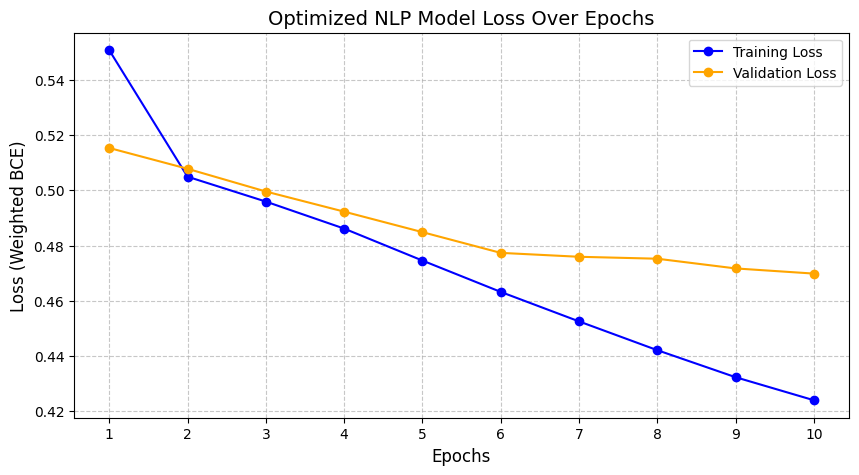

In [ ]:
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm

# --- 1. SETUP ---
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight_tensor)
optimizer = optim.Adam(nlp_model_opt.parameters(), lr=1e-4)

epochs = 10
train_losses_opt = []
val_losses_opt = []

best_val_loss = float('inf')
best_epoch = -1

# --- 2. TRAINING & VALIDATION LOOP ---
for epoch in range(epochs):
    # --- TRAINING PHASE ---
    nlp_model_opt.train()
    running_train_loss = 0.0

    progress_bar = tqdm(nlp_train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]")

    for texts, labels in progress_bar:
        texts, labels = texts.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = nlp_model_opt(texts)
        loss = criterion(outputs, labels)
        loss.backward()

        # Optional: Use gradient clipping to prevent exploding gradients
        torch.nn.utils.clip_grad_norm_(nlp_model_opt.parameters(), max_norm=1.0)

        optimizer.step()

        running_train_loss += loss.item() * texts.size(0)
        progress_bar.set_postfix({'batch_loss': loss.item()})

    train_loss = running_train_loss / len(nlp_train_dataset)

    # --- VALIDATION PHASE ---
    nlp_model_opt.eval()
    running_val_loss = 0.0

    with torch.no_grad():
        for texts, labels in nlp_val_loader:
            texts, labels = texts.to(device), labels.to(device)

            outputs = nlp_model_opt(texts)
            loss = criterion(outputs, labels)

            running_val_loss += loss.item() * texts.size(0)

    val_loss = running_val_loss / len(nlp_val_dataset)

    # Save average losses for plotting
    train_losses_opt.append(train_loss)
    val_losses_opt.append(val_loss)

    # Save best model checkpoint
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch = epoch + 1
        torch.save(nlp_model_opt.state_dict(), "nlp_model_task2_opt_best.pth")

    print(f"Epoch {epoch+1}/{epochs} - Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

print(f"Best optimized model saved from epoch {best_epoch} with val loss {best_val_loss:.4f}")

# ==========================================
# --- VISUALIZATION LOSS CURVES ---
# ==========================================
plt.figure(figsize=(10, 5))
plt.plot(range(1, epochs+1), train_losses_opt, label='Training Loss', marker='o', color='blue')
plt.plot(range(1, epochs+1), val_losses_opt, label='Validation Loss', marker='o', color='orange')
plt.title('Optimized NLP Model Loss Over Epochs', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss (Weighted BCE)', fontsize=12)
plt.xticks(range(1, epochs+1))
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [76]:
torch.save(nlp_model_opt.state_dict(), "nlp_model_task2_opt_best.pth")
print("Optimized NLP model saved successfully.")

Optimized NLP model saved successfully.


In [77]:
# --- 3. EVALUATION ON TEST SET (ML-Small) ---
import torch
import numpy as np
from sklearn.metrics import f1_score, roc_auc_score

print("\nEvaluating Optimized Model on Test Set...")

nlp_model_opt.load_state_dict(torch.load("nlp_model_task2_opt_best.pth", map_location=device))
nlp_model_opt.eval()

all_targets_opt = []
all_predictions_opt = []
all_probabilities_opt = []

with torch.no_grad():
    for texts, labels in nlp_test_loader:
        texts = texts.to(device)

        outputs = nlp_model_opt(texts)
        probabilities = torch.sigmoid(outputs).cpu().numpy()
        predictions = (probabilities >= 0.3).astype(np.int64)

        targets = labels.cpu().numpy()
        targets = (targets > 0.5).astype(np.int64)

        all_probabilities_opt.append(probabilities)
        all_predictions_opt.append(predictions)
        all_targets_opt.append(targets)

all_probabilities_opt = np.vstack(all_probabilities_opt).astype(np.float32)
all_predictions_opt = np.vstack(all_predictions_opt).astype(np.int64)
all_targets_opt = np.vstack(all_targets_opt).astype(np.int64)

print("all_targets shape:", all_targets_opt.shape)
print("all_predictions shape:", all_predictions_opt.shape)
print("Unique targets:", np.unique(all_targets_opt))
print("Unique preds:", np.unique(all_predictions_opt))

macro_f1_opt = f1_score(all_targets_opt, all_predictions_opt, average='macro', zero_division=0)
micro_f1_opt = f1_score(all_targets_opt, all_predictions_opt, average='micro', zero_division=0)
roc_auc_opt = roc_auc_score(all_targets_opt, all_probabilities_opt, average='macro')

print(f"Optimized Test Macro F1-Score: {macro_f1_opt:.4f}")
print(f"Optimized Test Micro F1-Score: {micro_f1_opt:.4f}")
print(f"Optimized Test ROC-AUC Score: {roc_auc_opt:.4f}")


Evaluating Optimized Model on Test Set...
all_targets shape: (9617, 19)
all_predictions shape: (9617, 19)
Unique targets: [0 1]
Unique preds: [0 1]
Optimized Test Macro F1-Score: 0.2646
Optimized Test Micro F1-Score: 0.4065
Optimized Test ROC-AUC Score: 0.6886


In [78]:
import torch
import numpy as np
from sklearn.metrics import f1_score

print("Searching for best threshold on validation set for optimized bidirectional model...")

nlp_model_opt.load_state_dict(torch.load("nlp_model_task2_opt_best.pth", map_location=device))
nlp_model_opt.eval()

all_val_targets_opt = []
all_val_probabilities_opt = []

with torch.no_grad():
    for texts, labels in nlp_val_loader:
        texts = texts.to(device)

        outputs = nlp_model_opt(texts)
        probabilities = torch.sigmoid(outputs).cpu().numpy()

        targets = labels.cpu().numpy()
        targets = (targets > 0.5).astype(np.int64)

        all_val_probabilities_opt.append(probabilities)
        all_val_targets_opt.append(targets)

all_val_probabilities_opt = np.vstack(all_val_probabilities_opt)
all_val_targets_opt = np.vstack(all_val_targets_opt)

thresholds = [0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50, 0.55]
best_threshold_opt = 0.5
best_macro_f1_opt = -1

for th in thresholds:
    preds = (all_val_probabilities_opt >= th).astype(np.int64)

    macro = f1_score(all_val_targets_opt, preds, average='macro', zero_division=0)
    micro = f1_score(all_val_targets_opt, preds, average='micro', zero_division=0)

    print(f"Threshold={th:.2f} | Macro F1={macro:.4f} | Micro F1={micro:.4f}")

    if macro > best_macro_f1_opt:
        best_macro_f1_opt = macro
        best_threshold_opt = th

print(f"\nBest threshold for optimized bidirectional model: {best_threshold_opt:.2f}")

Searching for best threshold on validation set for optimized bidirectional model...
Threshold=0.20 | Macro F1=0.2048 | Micro F1=0.3595
Threshold=0.25 | Macro F1=0.2178 | Micro F1=0.3983
Threshold=0.30 | Macro F1=0.2286 | Micro F1=0.4294
Threshold=0.35 | Macro F1=0.2335 | Micro F1=0.4505
Threshold=0.40 | Macro F1=0.2354 | Micro F1=0.4596
Threshold=0.45 | Macro F1=0.2287 | Micro F1=0.4553
Threshold=0.50 | Macro F1=0.2181 | Micro F1=0.4305
Threshold=0.55 | Macro F1=0.1875 | Micro F1=0.3758

Best threshold for optimized bidirectional model: 0.40


In [79]:
# --- FINAL EVALUATION ON TEST SET USING BEST THRESHOLD (OPTIMIZED BIDIRECTIONAL MODEL) ---
import torch
import numpy as np
from sklearn.metrics import f1_score, roc_auc_score

print("\nEvaluating optimized bidirectional model on Test Set with tuned threshold...")

nlp_model_opt.load_state_dict(torch.load("nlp_model_task2_opt_best.pth", map_location=device))
nlp_model_opt.eval()

all_targets_opt = []
all_predictions_opt = []
all_probabilities_opt = []

with torch.no_grad():
    for texts, labels in nlp_test_loader:
        texts = texts.to(device)

        outputs = nlp_model_opt(texts)
        probabilities = torch.sigmoid(outputs).cpu().numpy()
        predictions = (probabilities >= best_threshold_opt).astype(np.int64)

        targets = labels.cpu().numpy()
        targets = (targets > 0.5).astype(np.int64)

        all_probabilities_opt.append(probabilities)
        all_predictions_opt.append(predictions)
        all_targets_opt.append(targets)

all_probabilities_opt = np.vstack(all_probabilities_opt).astype(np.float32)
all_predictions_opt = np.vstack(all_predictions_opt).astype(np.int64)
all_targets_opt = np.vstack(all_targets_opt).astype(np.int64)

print("all_targets shape:", all_targets_opt.shape)
print("all_predictions shape:", all_predictions_opt.shape)
print("Unique targets:", np.unique(all_targets_opt))
print("Unique preds:", np.unique(all_predictions_opt))

macro_f1_opt = f1_score(all_targets_opt, all_predictions_opt, average='macro', zero_division=0)
micro_f1_opt = f1_score(all_targets_opt, all_predictions_opt, average='micro', zero_division=0)
roc_auc_opt = roc_auc_score(all_targets_opt, all_probabilities_opt, average='macro')

print(f"Optimized Bidirectional Test Macro F1-Score: {macro_f1_opt:.4f}")
print(f"Optimized Bidirectional Test Micro F1-Score: {micro_f1_opt:.4f}")
print(f"Optimized Bidirectional Test ROC-AUC Score: {roc_auc_opt:.4f}")
print(f"Best threshold used: {best_threshold_opt:.2f}")


Evaluating optimized bidirectional model on Test Set with tuned threshold...
all_targets shape: (9617, 19)
all_predictions shape: (9617, 19)
Unique targets: [0 1]
Unique preds: [0 1]
Optimized Bidirectional Test Macro F1-Score: 0.2596
Optimized Bidirectional Test Micro F1-Score: 0.4157
Optimized Bidirectional Test ROC-AUC Score: 0.6886
Best threshold used: 0.40


Dynamic thresholding improves the final classification decision, but it does not create new embeddings. Therefore, extraction must use the trained bidirectional checkpoint, not the threshold rule.

In [80]:
# --- FINAL EXTRACTION USING THE SELECTED BEST OPTIMIZED MODEL ---
nlp_model_opt.load_state_dict(torch.load("nlp_model_task2_opt_best.pth", map_location=device))
nlp_model_opt.eval()

all_nlp_embeddings = []

with torch.no_grad():
    for texts, _ in nlp_test_loader:
        texts = texts.to(device)

        embeddings = nlp_model_opt.extract_embeddings(texts)
        all_nlp_embeddings.append(embeddings.cpu())

final_nlp_embeddings = torch.cat(all_nlp_embeddings, dim=0)

print(f"Extracted NLP Embeddings Shape: {final_nlp_embeddings.shape} -> [Num_Movies, Hidden_Dim]")

save_dict = {
    'movie_ids': torch.tensor(small_full['movieId'].values),
    'embeddings': final_nlp_embeddings
}

torch.save(save_dict, 'datasets/nlp_embeddings.pt')
print("Final optimized semantic NLP embeddings successfully saved to 'datasets/nlp_embeddings.pt'!")

Extracted NLP Embeddings Shape: torch.Size([9617, 512]) -> [Num_Movies, Hidden_Dim]
Final optimized semantic NLP embeddings successfully saved to 'datasets/nlp_embeddings.pt'!


## Part 3 — Graph-Based Movie Recommendation

The final stage integrates the learned visual and textual movie representations into a graph-based recommendation framework.

Users and movies are represented as two different node types in a **bipartite heterogeneous graph**, while observed user–movie interactions define `rates` edges between them.

The recommendation problem is formulated as **link prediction**: given a user and a movie, the model estimates the likelihood of an interaction between them.

The experiments focus on constructing and comparing different movie-node feature representations:

- Baseline features
- Visual embeddings
- Textual embeddings
- Multimodal visual + textual embeddings
- Pretrained textual embeddings

These representations are evaluated within the same GraphSAGE-based framework to investigate how the choice of node features affects recommendation performance.

> **Implementation note:** The GraphSAGE architecture and core training loop were provided as part of the course assignment. The project work in this stage focused on node-feature construction, heterogeneous graph preparation, integration of the learned representations, experimentation, and comparative evaluation.

---
### **Graph Construction**
Graph frameworks require node IDs to be contiguous integers starting from $0$. MovieLens IDs (like `movieId = 5000`) will cause out-of-bounds errors if not mapped properly. The code below loads the ratings and creates mappings.

In [83]:
import torch
import pandas as pd
import numpy as np
from torch_geometric.data import HeteroData
import torch_geometric.transforms as T

# Load the ratings data from the small graph
ratings_df = pd.read_csv('./datasets/ml-latest-small/ratings.csv')

# Only keep ratings for movies that exist in our valid small_full set (with TMDB links)
small_full = pd.read_csv('./datasets/ml_small_metadata_full.csv')
valid_movie_ids = set(small_full['movieId'])
ratings_df = ratings_df[ratings_df['movieId'].isin(valid_movie_ids)]

# Create Contiguous IDs for Users and Movies
unique_users = ratings_df['userId'].unique()
unique_movies = small_full['movieId'].unique()  # Use the full valid subset, not just rated ones

user_mapping = {userid: i for i, userid in enumerate(unique_users)}
movie_mapping = {movieid: i for i, movieid in enumerate(unique_movies)}

# Map the edges
src = [user_mapping[uid] for uid in ratings_df['userId']]
dst = [movie_mapping[mid] for mid in ratings_df['movieId']]
edge_index = torch.tensor([src, dst], dtype=torch.long)

print(f"Total Users: {len(user_mapping)}")
print(f"Total Movies: {len(movie_mapping)}")
print(f"Total Ratings (Edges): {edge_index.shape[1]}")

/opt/miniconda3/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Total Users: 610
Total Movies: 9617
Total Ratings (Edges): 100511


### Feature Engineering & Initialization

The heterogeneous graph uses different initial representations for users and movies.

Since no demographic or descriptive user metadata is available, user nodes are initialized with learnable embeddings. Movie nodes are represented using the features learned in the previous stages.

Several movie feature configurations are evaluated:

- **Baseline:** non-informative features used to measure how much can be learned from graph structure alone.
- **Visual:** embeddings extracted from the poster-based vision model.
- **Textual:** embeddings learned from movie plot summaries.
- **Multimodal:** concatenation of visual and textual embeddings.
- **Pretrained:** representations obtained from a pretrained and fine-tuned language model.

Using the same graph structure and recommendation framework across these experiments enables a controlled comparison of the contribution of each representation.

In [84]:
cv_data = torch.load('./datasets/cv_embeddings.pt')
cv_features = cv_data['embeddings']  # Shape: [Num_Movies, 512]

nlp_data = torch.load('./datasets/nlp_embeddings.pt')
nlp_features = nlp_data['embeddings']  # Shape: [Num_Movies, ...]

The extracted visual and textual embeddings are aligned with the movie-node ordering used by the graph. The following checks verify this alignment before feature normalization and graph construction.

In [85]:
import torch
import pandas as pd

small_full = pd.read_csv('./datasets/ml_small_metadata_full.csv')

cv_data = torch.load('./datasets/cv_embeddings.pt')
nlp_data = torch.load('./datasets/nlp_embeddings.pt')

small_movie_ids = torch.tensor(small_full['movieId'].values)

print("CV order matches small_full:", torch.equal(cv_data['movie_ids'], small_movie_ids))
print("NLP order matches small_full:", torch.equal(nlp_data['movie_ids'], small_movie_ids))

print("First 10 movieIds from small_full:", small_movie_ids[:10])
print("First 10 movieIds from CV file:", cv_data['movie_ids'][:10])
print("First 10 movieIds from NLP file:", nlp_data['movie_ids'][:10])

CV order matches small_full: True
NLP order matches small_full: True
First 10 movieIds from small_full: tensor([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10])
First 10 movieIds from CV file: tensor([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10])
First 10 movieIds from NLP file: tensor([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10])


In [ ]:
import torch
import torch.nn.functional as F

# Load saved embeddings from local datasets folder
cv_data = torch.load('./datasets/cv_embeddings.pt')
cv_features = cv_data['embeddings']   # e.g. [Num_Movies, 512]

nlp_data = torch.load('./datasets/nlp_embeddings.pt')
nlp_features = nlp_data['embeddings'] # e.g. [Num_Movies, 256] or [Num_Movies, 512]

def get_movie_features(strategy, cv_feats, nlp_feats, num_movies):
    """Returns the appropriate node feature tensor based on the selected ablation strategy."""
    if strategy == "baseline":
        return torch.randn((num_movies, 64))

    elif strategy == "cv":
        # Return the L2-normalized visual embeddings 
        return F.normalize(cv_feats, p=2, dim=1)

    elif strategy == "nlp":
        # Return the L2-normalized semantic embeddings 
        return F.normalize(nlp_feats, p=2, dim=1)

    elif strategy == "multimodal":
        # Concatenate the CV and NLP features, then normalize
        combined = torch.cat([cv_feats, nlp_feats], dim=1)
        return F.normalize(combined, p=2, dim=1)

    elif strategy == "pretrained":
        # Load the provided pretrained NLP embeddings and normalize
        pretrained_feats = torch.load('./datasets/pretrained_nlp_embeddings.pt', map_location='cpu')
        return F.normalize(pretrained_feats, p=2, dim=1)

    else:
        raise ValueError("Invalid strategy! Please choose 'baseline', 'cv', 'nlp', 'multimodal', or 'pretrained'.")

This function transforms raw data into a **Bipartite Heterogeneous Graph**. In high-level terms, it sets up the "map" that the GNN will use to navigate and learn.

* **`HeteroData()`**: Instead of a simple list, we initialize a specialized container that recognizes different "species" of nodes (Users vs. Movies) and their specific relationships.
* **User Nodes (Structural IDs)**: We tell the graph how many users exist. Since we have no metadata for them, the GNN will later assign them unique, learnable "fingerprints" (embeddings) based purely on their position in the graph.
* **Movie Nodes (Semantic Features)**: Unlike users, movies are initialized with the rich features you extracted (CV/NLP). This allows the GNN to understand *what* a movie is, rather than just knowing its ID.
* **Edge Index (The Connections)**: This maps the "rates" relationship. It acts as the bridge that tells the model which users interacted with which movies.
* **`T.ToUndirected()` (Two-Way Communication)**: By default, a rating is one-way (User $\to$ Movie). This transform creates "reverse" edges so that information can flow from movies back to users, allowing the GNN to perform complex message passing.

In [87]:
from torch_geometric.data import HeteroData
import torch_geometric.transforms as T

def build_graph(movie_features):
    data = HeteroData()

    # User nodes just need to know how many exist
    data['user'].num_nodes = len(user_mapping)

    # Movie nodes require the actual semantic features
    data['movie'].x = movie_features

    # Add Edges
    data['user', 'rates', 'movie'].edge_index = edge_index

    # GNNs need undirected paths to pass messages back and forth
    data = T.ToUndirected()(data)

    return data

### GraphSAGE Architecture and Link Prediction

The recommendation model uses **GraphSAGE** to propagate information through the heterogeneous user–movie graph.

The model consists of two main components:

- **Encoder:** GraphSAGE layers aggregate information from neighboring nodes and generate latent representations for users and movies.
- **Decoder:** The learned user and movie representations are combined to produce a score for each candidate user–movie interaction.

The model is trained as a **binary link prediction** problem, distinguishing observed interactions from negative user–movie pairs.

To ensure a fair comparison, the same GraphSAGE architecture and training procedure are used across all feature configurations. Only the movie-node representations are changed between experiments.

> The GraphSAGE architecture and core training procedure were provided as part of the course framework and are retained here to make the experimental pipeline complete and reproducible.

In [88]:
import torch.nn.functional as F
from torch_geometric.nn import SAGEConv, HeteroConv

class HeteroGNNEncoder(nn.Module):
    def __init__(self, hidden_channels, out_channels):
        super().__init__()
        # HeteroConv allows us to define specific message passing for specific edge types.
        self.conv1 = HeteroConv({
            ('user', 'rates', 'movie'): SAGEConv((-1, -1), hidden_channels),
            ('movie', 'rev_rates', 'user'): SAGEConv((-1, -1), hidden_channels),
        }, aggr='sum')

        self.conv2 = HeteroConv({
            ('user', 'rates', 'movie'): SAGEConv((-1, -1), out_channels),
            ('movie', 'rev_rates', 'user'): SAGEConv((-1, -1), out_channels),
        }, aggr='sum')

    def forward(self, x_dict, edge_index_dict):
        x_dict = self.conv1(x_dict, edge_index_dict)
        x_dict = {key: F.relu(x) for key, x in x_dict.items()}
        x_dict = self.conv2(x_dict, edge_index_dict)
        return x_dict


class EdgeDecoder(nn.Module):
    def __init__(self, hidden_channels):
        super().__init__()
        # Decodes the probability of a link by concatenating User and Movie embeddings
        self.lin1 = nn.Linear(2 * hidden_channels, hidden_channels)
        self.lin2 = nn.Linear(hidden_channels, 1)

    def forward(self, z_dict, edge_label_index):
        row, col = edge_label_index
        # Get the embeddings for the source (User) and destination (Movie)
        z = torch.cat([z_dict['user'][row], z_dict['movie'][col]], dim=-1)
        z = F.relu(self.lin1(z))
        z = self.lin2(z)
        return z.view(-1)


class RecommenderGNN(nn.Module):
    def __init__(self, hidden_channels, num_users, movie_feature_dim):
        super().__init__()
        # 1. Structural Embedding for Users (They have no metadata)
        self.user_emb = nn.Embedding(num_users, hidden_channels)

        # 2. Projection Layer for Movies
        self.movie_proj = nn.Linear(movie_feature_dim, hidden_channels)

        self.encoder = HeteroGNNEncoder(hidden_channels, hidden_channels)
        self.decoder = EdgeDecoder(hidden_channels)

    def forward(self, x_dict, edge_index_dict, edge_label_index):
        # Initialize node representations
        h_dict = {
            'user': self.user_emb.weight,
            'movie': self.movie_proj(x_dict['movie'])
        }

        # Pass through GraphSAGE layers
        z_dict = self.encoder(h_dict, edge_index_dict)

        # Decode the requested edges
        return self.decoder(z_dict, edge_label_index)

### Transductive Link Prediction

Unlike the visual and textual representation models, which are evaluated on separate examples, the graph recommendation stage uses a **transductive link-prediction setting**.

The full set of user and movie nodes is retained while observed interactions are split into training, validation, and test edges. Message passing is performed over the available training structure, and evaluation measures the model's ability to predict held-out user–movie links.

`RandomLinkSplit` is used to create the edge-level splits and negative samples required for training and evaluation.

Graph machine learning often relies on **transductive learning**.
* In a transductive setup, the model sees the *entire graph structure* (all User and Movie nodes) during the training phase.
* Because we can't easily isolate nodes without breaking the graph, we split **edges** instead of nodes.
* We hide a percentage of the "rates" edges to serve as our test set. The model learns by passing messages across the visible training edges, and we evaluate it by asking it to predict the existence of the edges we hid.

Regarding T.RandomLinkSplit:
* **`num_val=0.1` and `num_test=0.1`**: We hide 10% of the rating edges for validation and 10% for final testing. The remaining 80% are our training edges.
* **`disjoint_train_ratio=0.3`**: This is a crucial defense against data leakage. Of our 80% training edges, we separate them into two buckets. 70% are strictly used for **message passing** (building the node embeddings). The other 30% are used strictly as **supervision targets** (calculating the loss). If we let the GNN pass messages over the exact same edge it is trying to predict, it would be cheating!

In [94]:
import torch
import torch.nn.functional as F
from torch_geometric.data import HeteroData
import torch_geometric.transforms as T
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score
from tqdm.auto import tqdm

# --- TRAINING & EVALUATION LOOP ---
def train_and_evaluate_graph(graph_data, num_epochs=40, hidden_channels=64, lr=0.01, patience=5):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # Create Train/Val/Test Link Splits (Negative Sampling)
    transform = T.RandomLinkSplit(
        num_val=0.1,
        num_test=0.1,
        disjoint_train_ratio=0.3,
        neg_sampling_ratio=1.0,
        add_negative_train_samples=True,
        edge_types=[('user', 'rates', 'movie')],
        rev_edge_types=[('movie', 'rev_rates', 'user')]
    )

    train_data, val_data, test_data = transform(graph_data)
    train_data = train_data.to(device)
    val_data = val_data.to(device)
    test_data = test_data.to(device)

    movie_feature_dim = graph_data['movie'].x.shape[1]
    num_users = graph_data['user'].num_nodes

    # Initialize Model
    model = RecommenderGNN(hidden_channels, num_users, movie_feature_dim).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = torch.nn.BCEWithLogitsLoss()

    history = {'loss': [], 'val_auc': []}

    best_val_auc = -1
    best_state_dict = None
    epochs_without_improvement = 0

    for epoch in range(num_epochs):
        model.train()
        optimizer.zero_grad()

        out = model(
            train_data.x_dict,
            train_data.edge_index_dict,
            train_data['user', 'rates', 'movie'].edge_label_index
        )

        target = train_data['user', 'rates', 'movie'].edge_label.float()
        loss = criterion(out, target)
        loss.backward()
        optimizer.step()

        history['loss'].append(loss.item())

        # Validation
        model.eval()
        with torch.no_grad():
            val_out = model(
                val_data.x_dict,
                val_data.edge_index_dict,
                val_data['user', 'rates', 'movie'].edge_label_index
            )

            val_pred = torch.sigmoid(val_out).cpu().numpy()
            val_target = val_data['user', 'rates', 'movie'].edge_label.cpu().numpy()

            val_auc = roc_auc_score(val_target, val_pred)
            history['val_auc'].append(val_auc)

        # Check improvement
        if val_auc > best_val_auc:
            best_val_auc = val_auc
            best_state_dict = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        # Early stopping
        if epochs_without_improvement >= patience:
            print(f"Early stopping at epoch {epoch+1}. Best Val AUC: {best_val_auc:.4f}")
            break

    # Load the best validation model before returning
    if best_state_dict is not None:
        model.load_state_dict(best_state_dict)

    return history, model

In [95]:
num_movies = len(movie_mapping)
strategies = ['baseline', 'cv', 'nlp', 'multimodal', 'pretrained']

Training Strategy: BASELINE
Early stopping at epoch 24. Best Val AUC: 0.9254
Training Strategy: CV
Early stopping at epoch 39. Best Val AUC: 0.9326
Training Strategy: NLP
Training Strategy: MULTIMODAL
Training Strategy: PRETRAINED
Early stopping at epoch 37. Best Val AUC: 0.9337


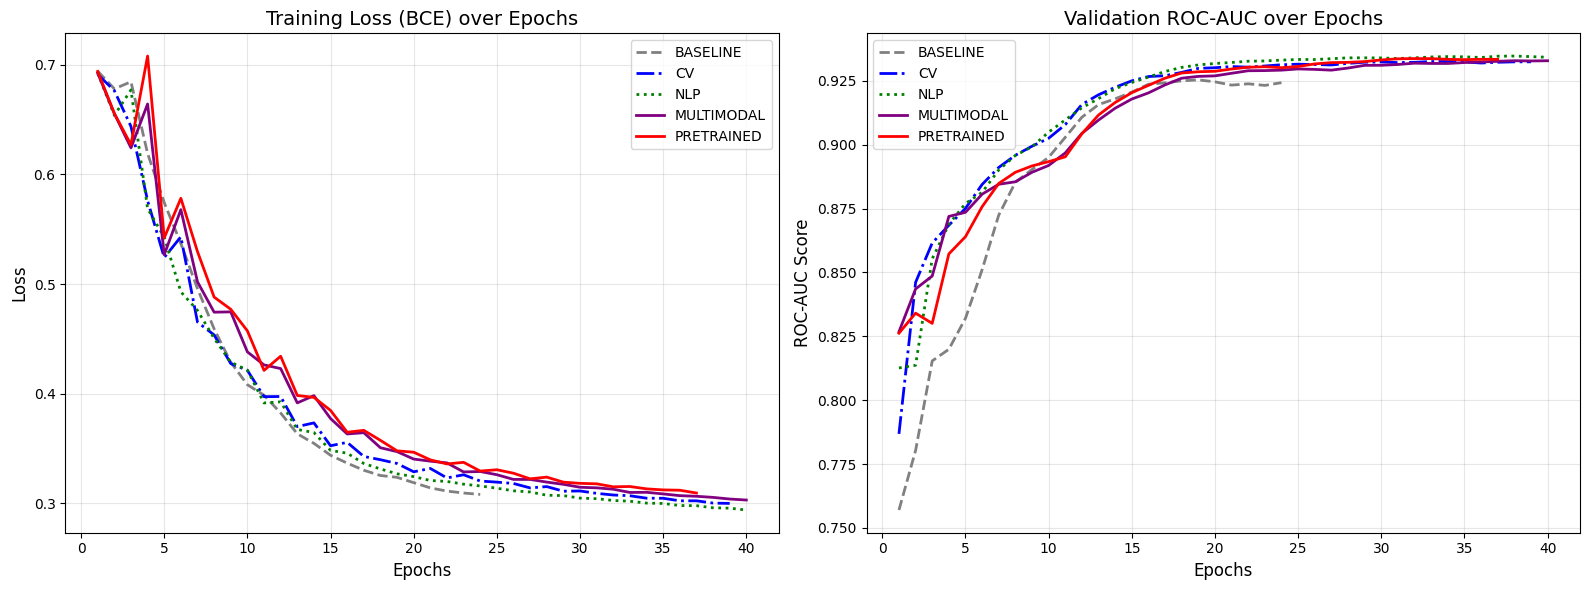

In [97]:
results = {}
for strategy in strategies:
    print(f"Training Strategy: {strategy.upper()}")

    # 1. Get features using the helper function
    features = get_movie_features(strategy, cv_features, nlp_features, num_movies)

    # 2. Build the PyG HeteroData Graph
    graph = build_graph(features)

    # 3. Train and Evaluate
    history, _ = train_and_evaluate_graph(graph, num_epochs=40)
    results[strategy] = history

# --- PLOTTING THE COMPARISON ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
styles = ['--', '-.', ':', '-', '-']
colors = ['gray', 'blue', 'green', 'purple', 'red']

for i, (name, history) in enumerate(results.items()):
    epochs = range(1, len(history['loss']) + 1)

    ax1.plot(epochs, history['loss'], linestyle=styles[i], color=colors[i], label=name.upper(), linewidth=2)
    ax2.plot(epochs, history['val_auc'], linestyle=styles[i], color=colors[i], label=name.upper(), linewidth=2)

ax1.set_title('Training Loss (BCE) over Epochs', fontsize=14)
ax1.set_xlabel('Epochs', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.grid(True, alpha=0.3)
ax1.legend()

ax2.set_title('Validation ROC-AUC over Epochs', fontsize=14)
ax2.set_xlabel('Epochs', fontsize=12)
ax2.set_ylabel('ROC-AUC Score', fontsize=12)
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()

In [99]:
print("FINAL STRATEGY COMPARISON")
for name, history in results.items():
    print(
        f"{name.upper():12s} | "
        f"Best Val AUC: {max(history['val_auc']):.4f} | "
        f"Final Val AUC: {history['val_auc'][-1]:.4f}"
    )

FINAL STRATEGY COMPARISON
BASELINE     | Best Val AUC: 0.9254 | Final Val AUC: 0.9243
CV           | Best Val AUC: 0.9326 | Final Val AUC: 0.9324
NLP          | Best Val AUC: 0.9347 | Final Val AUC: 0.9342
MULTIMODAL   | Best Val AUC: 0.9329 | Final Val AUC: 0.9329
PRETRAINED   | Best Val AUC: 0.9337 | Final Val AUC: 0.9334


### Experimental Analysis

The comparison highlights the relative contribution of graph structure and movie-node features to recommendation performance. It also provides a controlled comparison between visual, textual, multimodal, and pretrained representations.

1. Even with random movie features, the GNN can still learn from the graph structure itself, since the user–movie edges already reveal patterns such as     which users have similar tastes, which movies are often connected to similar groups of users and which users and movies belong to the same neighborhoods. So the model is not relying only on node features. It is also learning from the connectivity pattern of the graph. This shows that in recommendation tasks the edges play a very important role.

2.  Yes, there are differences between modalities. All feature-based methods performed better than the baseline, which shows that movie features help the recommendation task. Among them, NLP performed best, slightly better than CV, multimodal, and pretrained features. This suggests that plot information was the most useful modality in our experiments, probably because it captures the semantic content of the movie more directly than the poster image.

3.  No, the pretrained embeddings did not give the best performance in our case. They performed well, but the custom NLP embeddings achieved the highest validation ROC-AUC. A possible reason is that our extracted NLP embeddings were more directly adapted to the specific movie-plot classification task, so they matched the recommendation setting better than the generic pretrained representations.

### Qualitative Recommendation Analysis

In addition to ROC-AUC evaluation, the trained model is used to generate human-readable movie recommendations.

For a selected user, movies already present in the user's interaction history are excluded from the candidate set. The remaining user–movie pairs are scored by the trained GNN and ranked according to their predicted link probability.

The highest-scoring unseen movies form the **Top-5 recommendation list**, providing a qualitative view of the behavior of the recommendation model.

In [100]:
import torch
import pandas as pd
import numpy as np

def recommend_movies_for_user(user_id, model, graph_data, metadata_df, user_mapping, movie_mapping, top_k=5):
    """Generates human-readable movie recommendations for a specific user in the following fomat:
    --- USER X HISTORY ---
    They have already rated N movies. Here are a few:
       Movie 1
       Movie 2
       Movie 3
       Movie 4
       Movie 5


    --- TOP 5 GNN RECOMMENDATIONS ---
       Movie 1 (Probability)
       Movie 2 (Probability)
       Movie 3 (Probability)
       Movie 4 (Probability)
       Movie 5 (Probability)
    """
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)
    graph_data = graph_data.to(device)
    model.eval()

    # 1. Reverse movie mapping and make title lookup
    reverse_movie_mapping = {v: k for k, v in movie_mapping.items()}
    movieid_to_title = dict(zip(metadata_df['movieId'], metadata_df['title']))

    # 2. Get internal graph user id
    if user_id not in user_mapping:
        print(f"User {user_id} is not in the graph.")
        return

    user_graph_id = user_mapping[user_id]

    # 3. Find movies already rated by this user
    full_edge_index = graph_data['user', 'rates', 'movie'].edge_index.cpu()
    user_mask = (full_edge_index[0] == user_graph_id)
    rated_movie_graph_ids = full_edge_index[1][user_mask].tolist()

    rated_movie_ids = [reverse_movie_mapping[mid] for mid in rated_movie_graph_ids]
    rated_titles = [movieid_to_title.get(mid, f"MovieLens ID {mid}") for mid in rated_movie_ids]

    print(f"\n--- USER {user_id} HISTORY ---")
    print(f"They have already rated {len(rated_titles)} movies. Here are a few:")
    for title in rated_titles[:5]:
        print(f"   {title}")

    # 4. Candidate movies = all unrated movies
    all_movie_graph_ids = set(movie_mapping.values())
    rated_movie_graph_ids_set = set(rated_movie_graph_ids)
    candidate_movie_graph_ids = sorted(list(all_movie_graph_ids - rated_movie_graph_ids_set))

    # 5. Build pred_edge_index
    pred_edge_index = torch.tensor(
        [
            [user_graph_id] * len(candidate_movie_graph_ids),
            candidate_movie_graph_ids
        ],
        dtype=torch.long,
        device=device
    )

    # 6. Forward pass for candidate edges
    with torch.no_grad():
        logits = model(
            graph_data.x_dict,
            graph_data.edge_index_dict,
            pred_edge_index
        )
        probs = torch.sigmoid(logits).cpu().numpy()

    # 7. Top-k ranking
    top_indices = np.argsort(probs)[-top_k:][::-1]

    print(f"\n--- TOP {top_k} GNN RECOMMENDATIONS ---")
    for idx in top_indices:
        movie_graph_id = candidate_movie_graph_ids[idx]
        movie_id = reverse_movie_mapping[movie_graph_id]
        title = movieid_to_title.get(movie_id, f"MovieLens ID {movie_id}")
        prob = probs[idx]
        print(f"   {title} ({prob:.4f})")

In [101]:
best_strategy = "nlp"

graph = build_graph(get_movie_features(best_strategy, cv_features, nlp_features, num_movies))
_, model = train_and_evaluate_graph(graph, num_epochs=40, patience=5)

recommend_movies_for_user(
    user_id=42,
    model=model,
    graph_data=graph,
    metadata_df=small_full,
    user_mapping=user_mapping,
    movie_mapping=movie_mapping,
    top_k=5
)


--- USER 42 HISTORY ---
They have already rated 439 movies. Here are a few:
   Grumpier Old Men (1995)
   Sabrina (1995)
   GoldenEye (1995)
   American President, The (1995)
   Casino (1995)

--- TOP 5 GNN RECOMMENDATIONS ---
   Waterworld (1995) (0.9825)
   Quiz Show (1994) (0.9815)
   Speed (1994) (0.9811)
   While You Were Sleeping (1995) (0.9792)
   Twister (1996) (0.9789)


## Experimental Summary

The final experiments compare several movie-node feature configurations within the same graph-based recommendation setting, including baseline, visual, textual, multimodal, and pretrained representations. The textual representation produced the strongest validation result, with an AUC of approximately **0.935**.

Together, the experiments illustrate how information from different modalities can be transformed into node representations and evaluated within a common recommendation framework.
